# Incremental Capstone Session 
**Course:** Applied Data Science with Python  
**Student Name:** `Brian Gaddy`  
**Date:** `03-22-2026`  

---

## 1. Objective

> Write 2–3 sentences here.  
> - What is the business problem?  
> - Who is the audience (CEO, S&M head, etc.)?  
> - What decision will this analysis support?

**Example:**  
*"AAL is an Australian apparel brand looking to expand. The CEO needs to identify which states generate the highest revenue and which need targeted sales programs. This analysis examines Q4 2020 sales data to provide state-wise and group-wise insights."*

## 2. Data Overview

| Field | Details |
|---|---|
| **Source** | *(e.g., AusApparalSales4thQrt2020.csv)* |
| **Rows** | *(fill after loading)* |
| **Columns** | *(fill after loading)* |
| **Date Range** | *(fill after loading)* |
| **Key Columns** | *(list the important ones)* |

## 3. Imports

In [21]:
# Import libraries and set the plot styling

# Preprocessing
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd
import numpy as np
from scipy import stats
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats.mstats import winsorize
from IPython.display import display
import math
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Supervised Learning
# CLUSTERING PIPELINE (K-Means, Hierarchical, DBSCAN, PCA, Profiling, Plotly)
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as shc
import plotly.express as px

#Regression
from sklearn import model_selection
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold, cross_val_predict, KFold
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor

#Classification
from sklearn.preprocessing import label_binarize
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, classification_report, confusion_matrix, r2_score, mean_squared_error, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import itertools
from itertools import cycle
from sklearn.naive_bayes import MultinomialNB
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from imblearn.under_sampling import RandomUnderSampler
from imblearn.ensemble import BalancedRandomForestClassifier

# Ensemble Learning
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from vecstack import stacking

# Unserpervised Learning Dimensionality reduction
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from pyECLAT import ECLAT
from sklearn.metrics.pairwise import cosine_similarity
import statistics
import operator
import scipy.sparse as sp
from scipy.sparse.linalg import svds
import logging
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from joblib import Parallel, delayed

# Surprise library for matrix factorization-based recommendation algorithms
import surprise
from surprise import SVD, NMF, KNNBasic
from surprise import Dataset, Reader
from surprise.model_selection import cross_validate

# ============================================================
# GLOBAL PLOT STYLE FOR CONSISTENT DASHBOARD VISUALS
# ============================================================

# Set Seaborn theme
sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=1.1
)

# Global Matplotlib settings
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 1.2,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.autolayout": True,
    "axes.grid": True,
    "grid.color": "#DDDDDD",
    "grid.linestyle": "--",
    "grid.linewidth": 0.7
})

# Consistent color palettes
HEATMAP_CMAP = "Blues"
CONFUSION_CMAP = "Purples"
ROC_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
              "#9467bd", "#8c564b", "#e377c2"]

# Function for consistent heatmaps
def plot_heatmap(df, title, cmap=HEATMAP_CMAP):
    plt.figure(figsize=(8, 5))
    sns.heatmap(df, annot=True, fmt=".2f", cmap=cmap, linewidths=0.5,annot_kws={"fontsize": 4})
    plt.title(title)
    plt.show()

# Function for consistent confusion matrices
def plot_confusion(cm, title):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=CONFUSION_CMAP, linewidths=0.5,annot_kws={"fontsize": 4})
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Function for consistent ROC curves
def plot_roc(fpr, tpr, auc_score, label):
    plt.plot(fpr, tpr, lw=2, label=f"{label} (AUC={auc_score:.2f})")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1.5)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# --- Load the dataset ---
df = pd.read_csv(r"C:\Users\brian\OneDrive\Desktop\AI and ML Certificate Program\Projects\Machine Learning\Creating_cohorts_of_songs\1751025363_datasets\rolling_stones_spotify.csv") # change to read_excel / read_json as needed
print("Libraries and Dataset loaded successfully!")
df.head()

Libraries and Dataset loaded successfully!


,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.08,0.46,0.99,1.00,0.93,-12.91,0.11,118.00,0.03,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.44,0.33,0.96,0.23,0.96,-4.80,0.08,131.46,0.32,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.42,0.39,0.97,0.40,0.96,-4.94,0.12,130.07,0.31,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.57,0.37,0.98,0.00,0.90,-5.54,0.19,132.99,0.15,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.40,0.30,0.97,0.06,0.97,-5.10,0.09,130.53,0.21,32,305106


# Preprocessing Pipeline

In [22]:
# LOGGING SETUP
# ============================================================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s"
)
logger = logging.getLogger(__name__)

# ============================================================
# 1. DATA INSPECTION
# ============================================================
# Quick Structural Overview
def inspect_data(df):
    import io

    # Inspecting the first few rows of the DataFrame
    print("\n=== HEAD ===")
    print(df.head().to_string(index=False))

    # Displaying the last few rows of the DataFrame
    print("\n=== TAIL ===")
    print(df.tail().to_string(index=False))

    # Providing information about the DataFrame, including data types and non-null counts
    print("\n=== INFO ===")
    buffer = io.StringIO()
    df.info(buf=buffer)
    info_str = buffer.getvalue()
    print(info_str)

    print("\n=== DESCRIBE ===")
    describe_df = df.describe().transpose()
    print(describe_df.to_string(index=True))

    # Displaying datatypes of the columns
    print("\n=== DTYPES ===")
    dtypes_df = pd.DataFrame(df.dtypes, columns=["dtype"])
    print(dtypes_df.to_string())

    print("\n=== SHAPE ===")
    print(df.shape)

    return df


# ============================================================
# 2. MISSING VALUES
# ============================================================
def analyze_missing(df):
    missing = df.isnull().sum()
    pct = (df.isna().sum() / len(df) * 100).round(2)
    missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage': pct})
    print("\n=== Missing Values ===")
    print(missing_df[missing_df['Missing Values'] > 0])
    return missing, pct

def handle_missing(df, strategy="median"):
    df_clean = df.copy()

    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    cat_cols = df_clean.select_dtypes(exclude=[np.number]).columns

# For numeric columns, we can use median or mean imputation
    if len(num_cols) > 0:
        imputer_num = SimpleImputer(strategy='mean') # Can be 'mean', 'median', 'most_frequent', or 'constant'
        df_clean[num_cols] = imputer_num.fit_transform(df_clean[num_cols])

    # For categorical columns, we can use the most frequent value or a constant placeholder
    if len(cat_cols) > 0:
        imputer_cat = SimpleImputer(strategy="most_frequent")
        df_clean[cat_cols] = imputer_cat.fit_transform(df_clean[cat_cols])

    return df_clean


# ============================================================
# 3. DUPLICATES
# ============================================================
def remove_duplicates(df):
    before = len(df)
    df_clean = df.drop_duplicates()
    after = len(df_clean)
    print((f"Removed {before - after} duplicate rows"))
    return df_clean


# ============================================================
# 4. DATA CLEANING
# ============================================================
class CleaningPipeline:

    @staticmethod
    def run(df, fix_negatives=False):
        df = clean_column_names(df)
        df = convert_categoricals(df) 
        if fix_negatives:
            df = handle_negative_values(df)
        df = fix_dates(df)
        df = extract_date_parts(df)
        df = clean_strings(df)
        return df

def clean_column_names(df):
    df_clean = df.copy() 

    # 1. Strip leading/trailing whitespace
    df_clean.columns = df_clean.columns.str.strip()

    # 2. Replace spaces with underscores
    df_clean.columns = df_clean.columns.str.replace(" ", "_")

    # 3. Remove special characters
    df_clean.columns = df_clean.columns.str.replace(r"[^A-Za-z0-9_]", "", regex=True)

    # 4. Convert to lowercase for consistency
    df_clean.columns = df_clean.columns.str.lower()

    return df_clean

def convert_categoricals(df):
    df_clean = df.copy()
    cat_cols = df_clean.select_dtypes(include=["object", "string"]).columns
    df_clean[cat_cols] = df_clean[cat_cols].astype("category")
    print("\n=== Converted Categorical Columns ===")
    print(f"Converted {len(cat_cols)} columns to 'category' dtype.\n")
    print("\n=== DataFrame Info After Cleaning ===")
    print(df_clean.info(),"\n")
    return df_clean

def handle_negative_values(df):
    df_clean = df.copy()

    # Identify numeric columns
    numeric_cols = [
        col for col in df_clean.columns
        if pd.api.types.is_numeric_dtype(df_clean[col])
    ]

    for col in numeric_cols:
        series = pd.to_numeric(df_clean[col], errors="coerce")

        # Mask negative values
        neg_mask = series < 0
        if neg_mask.any():
            neg_count = neg_mask.sum()

            # Replace negatives with NaN
            series[neg_mask] = np.nan

            # Fill with median
            median_val = series.median()
            series = series.fillna(median_val).astype("float64")

            df_clean[col] = series

            print(f"[negatives] Column '{col}': replaced {neg_count} negative values with median={median_val:.4f}")

    return df_clean

def fix_dates(df):
    df_clean = df.copy()
    for col in df_clean.columns:
        if "date" in col.lower():
            sample = df_clean[col].dropna().astype(str).head(20)
            if sample.str.contains(r"\d{1,4}[-/]\d{1,2}[-/]\d{1,4}|\d{4}", regex=True).any():
                try:
                    df_clean[col] = pd.to_datetime(df_clean[col], errors="coerce")
                except Exception as e:
                    logger.warning(f"Skipping date parsing for column '{col}': {e}")
            else:
                logger.info(f"Skipping non-date column: {col}")
    return df_clean

def extract_date_parts(df):
    df_clean = df.copy()
    for col in df_clean.columns:
        if pd.api.types.is_datetime64_any_dtype(df_clean[col]):
            df_clean[f"{col}_year"] = df_clean[col].dt.year
            df_clean[f"{col}_month"] = df_clean[col].dt.month
            df_clean[f"{col}_dayofweek"] = df_clean[col].dt.day_name()
    return df_clean

def clean_strings(df):
    df_clean = df.copy()
    for col in df_clean.select_dtypes(include=["object", "string"]).columns:
        df_clean[col] = df_clean[col].astype(str).str.strip().str.title()
    return df_clean


# ============================================================
# 5. FEATURE ENGINEERING (MODULAR + COLUMN-SPECIFIC + OUTLIERS)
# ============================================================

class FeatureEngineeringPipeline:

    @staticmethod
    def run(df, 
            outlier_cols=None,
            skew_threshold=1.0,
            winsor_limits=[0.05, 0.05],
            log_cols=None, 
            norm_cols=None, 
            bin_cols=None, 
            winsor_cols=None):

        df_out = df.copy()

        # --- AUTO OUTLIER HANDLING -----------------------------------------
        if outlier_cols:
            df_out = OutlierEngine.handle_outliers(
                df_out,
                cols=outlier_cols,
                skew_threshold=skew_threshold,
                winsor_limits=winsor_limits
            )

        # --- LOG TRANSFORM --------------------------------------------------
        if log_cols:
            df_out = add_log_features(df_out, log_cols)

        # --- NORMALIZATION --------------------------------------------------
        if norm_cols:
            df_out = normalize_columns(df_out, norm_cols)

        # --- BINNING --------------------------------------------------------
        if bin_cols:
            df_out = bin_numeric_columns(df_out, bin_cols)

        # --- MANUAL WINSORIZATION ------------------------------------------
        if winsor_cols:
            df_out = winsorize_columns(df_out, winsor_cols)

        return df_out


# ------------------------------------------------------------
# OUTLIER ENGINE (AUTO SKEW-BASED DECISION)
# ------------------------------------------------------------
class OutlierEngine:

    @staticmethod
    def handle_outliers(df, cols=None, skew_threshold=1.0, winsor_limits=[0.05, 0.05]):
        df_out = df.copy()

        if cols is None:
            cols = df_out.select_dtypes(include=[np.number]).columns.tolist()

        for col in cols:

            # Strict numeric conversion
            try:
                series = pd.to_numeric(df_out[col], errors="coerce")
            except Exception:
                logger.warning(f"[outliers] Column '{col}' cannot be converted to numeric. Skipping.")
                continue

            if series.isna().all():
                logger.warning(f"[outliers] Column '{col}' is all NaN after conversion. Skipping.")
                continue
           
            values = pd.to_numeric(df_out[col], errors="coerce").astype(float).to_numpy()

            # Remove NaN
            values = values[~np.isnan(values)]

            # Skip empty
            if len(values) == 0:
                logger.warning(f"[outliers] Column '{col}' has no valid numeric values. Skipping.")
                continue

            # Safe skew
            skew_val = pd.Series(values).skew()


            # Decide method
            if abs(skew_val) < skew_threshold:
                logger.info(f"[outliers] {col}: skew={skew_val:.2f} → Using IQR capping")
                df_out = OutlierEngine.apply_iqr_cap(df_out, col)
            else:
                logger.info(f"[outliers] {col}: skew={skew_val:.2f} → Using Winsorization")
                df_out = OutlierEngine.apply_winsor(df_out, col, winsor_limits)

        return df_out


    # ------------------------------------------------------------
    # IQR CAPPING
    # ------------------------------------------------------------
    @staticmethod
    def apply_iqr_cap(df, col):
        df_clean = df.copy()

        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        capped_col = f"{col}_iqr"

        df_clean[capped_col] = np.where(
            df_clean[col] < lower, lower,
            np.where(df_clean[col] > upper, upper, df_clean[col])
        )

        return df_clean


    # ------------------------------------------------------------
    # WINSORIZATION
    # ------------------------------------------------------------
    @staticmethod
    def apply_winsor(df, col, limits):
        df_clean = df.copy()
        winsor_col = f"{col}_winsor"

        try:
            df_clean[winsor_col] = winsorize(df_clean[col], limits=limits)
        except Exception as e:
            logger.error(f"[winsor] Failed on {col}: {e}")
            return df_clean

        return df_clean


# ============================================================
# LOG TRANSFORMATION
# ============================================================

def add_log_features(df, cols):
    df_clean = df.copy()

    for col in cols:
        if col not in df_clean.columns:
            logger.warning(f"[log] Column '{col}' not found. Skipping.")
            continue

        if not pd.api.types.is_numeric_dtype(df_clean[col]):
            logger.warning(f"[log] Column '{col}' is not numeric. Skipping.")
            continue

        if (df_clean[col] <= 0).any():
            logger.warning(f"[log] Column '{col}' contains non-positive values. Skipping.")
            continue

        df_clean[f"{col}_log"] = np.log1p(df_clean[col])

    return df_clean


# ============================================================
# NORMALIZATION (MIN-MAX)
# ============================================================

def normalize_columns(df, cols):
    df_clean = df.copy()

    for col in cols:
        if col not in df_clean.columns:
            logger.warning(f"[normalize] Column '{col}' not found. Skipping.")
            continue

        if not pd.api.types.is_numeric_dtype(df_clean[col]):
            logger.warning(f"[normalize] Column '{col}' is not numeric. Skipping.")
            continue

        col_min = df_clean[col].min()
        col_max = df_clean[col].max()

        if col_min == col_max:
            df_clean[f"{col}_norm"] = 0
        else:
            df_clean[f"{col}_norm"] = (df_clean[col] - col_min) / (col_max - col_min)

    return df_clean


# ============================================================
# BINNING
# ============================================================

def bin_numeric_columns(df, cols, bins=5, strategy="equal_width"):
    df_clean = df.copy()

    for col in cols:
        df_clean = bin_numeric(df_clean, col, bins=bins, strategy=strategy)

    return df_clean


def bin_numeric(df, col, bins=5, strategy="equal_width"):
    df_clean = df.copy()

    if col not in df_clean.columns:
        logger.warning(f"[bin] Column '{col}' not found. Skipping.")
        return df_clean

    if not pd.api.types.is_numeric_dtype(df_clean[col]):
        logger.warning(f"[bin] Column '{col}' is not numeric. Skipping.")
        return df_clean

    if strategy == "equal_width":
        df_clean[f"{col}_bin"] = pd.cut(df_clean[col], bins=bins)
    elif strategy == "quantile":
        df_clean[f"{col}_bin"] = pd.qcut(df_clean[col], q=bins, duplicates="drop")
    else:
        logger.warning(f"[bin] Unknown strategy '{strategy}'.")

    return df_clean


# ============================================================
# MANUAL WINSORIZATION
# ============================================================

def winsorize_columns(df, cols, limits=[0.05, 0.05]):
    df_clean = df.copy()

    for col in cols:
        df_clean = winsorize_column(df_clean, col, limits=limits)

    return df_clean


def winsorize_column(df, col, limits=[0.05, 0.05]):
    df_clean = df.copy()

    if col not in df_clean.columns:
        logger.warning(f"[winsor] Column '{col}' not found. Skipping.")
        return df_clean

    if not pd.api.types.is_numeric_dtype(df_clean[col]):
        logger.warning(f"[winsor] Column '{col}' is not numeric. Skipping.")
        return df_clean

    df_clean[f"winsorized_{col}"] = winsorize(df_clean[col], limits=limits)
    return df_clean


# ============================================================
# 8. GENERIC JOIN / CONCAT / MERGE (Smart Mode)
# ============================================================
class JoinEngine:

    @staticmethod
    def detect_keys(df1, df2):
        keys = set(df1.columns).intersection(df2.columns)
        id_keys = [(c1, c2) for c1 in df1.columns for c2 in df2.columns
                   if c1.lower().endswith("id") and c2.lower().endswith("id")]
        return list(keys) + id_keys

    @staticmethod
    def join(df1, df2, how="inner", left_key=None, right_key=None):
        if left_key is None or right_key is None:
            detected = JoinEngine.detect_keys(df1, df2)
            if not detected:
                logger.warning("No join keys detected.")
                return None
            if isinstance(detected[0], str):
                left_key = right_key = detected[0]
            else:
                left_key, right_key = detected[0]

        try:
            return pd.merge(df1, df2, left_on=left_key, right_on=right_key, how=how)
        except Exception as e:
            logger.error(f"Join failed: {e}")
            return None

    @staticmethod
    def concat(dfs, axis=0):
        try:
            return pd.concat(dfs, axis=axis, ignore_index=(axis==0))
        except Exception as e:
            logger.error(f"Concat failed: {e}")
            return None
    

# ============================================================
# 13. MASTER PIPELINE (Generic, Smart Mode)
# ============================================================

def generic_data_pipeline(
    df,
    *,
    # Feature engineering controls
    outlier_cols=None,
    skew_threshold=1.0,
    winsor_limits=[0.05, 0.05],
    log_cols=None,
    norm_cols=None,
    bin_cols=None,
    winsor_cols=None,
    # Join controls
    join_df=None,
    perform_demo_joins=True
):
    logger.info("=== STEP 1: INSPECTION ===")
    inspect_data(df)

    logger.info("=== STEP 2: MISSING VALUES ===")
    analyze_missing(df)
    df = handle_missing(df)

    logger.info("=== STEP 3: DUPLICATES ===")
    df = remove_duplicates(df)

    logger.info("=== STEP 4: CLEANING ===")
    df = CleaningPipeline.run(df)

    logger.info("=== STEP 5: FEATURE ENGINEERING ===")
    df = FeatureEngineeringPipeline.run(
        df=df,
        outlier_cols=outlier_cols,
        skew_threshold=skew_threshold,
        winsor_limits=winsor_limits,
        log_cols=log_cols,
        norm_cols=norm_cols,
        bin_cols=bin_cols,
        winsor_cols=winsor_cols
    )

    logger.info("=== STEP 6: JOINING (SMART MODE) ===")
    if join_df is not None:
        joined = JoinEngine.join(df, join_df)
        if joined is not None:
            logger.info(f"Smart join completed: {joined.shape}")
            if perform_demo_joins:
                df = joined  # optionally propagate joined data


    logger.info("=== PIPELINE COMPLETE ===")
    return df


# Example call
df_processed = generic_data_pipeline(
    df,
    outlier_cols=[
        col for col in df.columns
        if pd.api.types.is_numeric_dtype(df[col])
    ],
    log_cols=[c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and (df[c] > 0).all()],
    norm_cols=[c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])],
    bin_cols=[c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])],

    # Optional: manual winsorization (leave empty unless needed)
    winsor_cols=None
)

2026-05-06 20:27:43,625 — INFO — === STEP 1: INSPECTION ===
2026-05-06 20:27:43,679 — INFO — === STEP 2: MISSING VALUES ===
2026-05-06 20:27:43,710 — INFO — === STEP 3: DUPLICATES ===
2026-05-06 20:27:43,710 — INFO — === STEP 4: CLEANING ===
2026-05-06 20:27:43,753 — INFO — === STEP 5: FEATURE ENGINEERING ===
2026-05-06 20:27:43,756 — WARNING — [outliers] Column 'Unnamed: 0' cannot be converted to numeric. Skipping.
2026-05-06 20:27:43,760 — INFO — [outliers] track_number: skew=1.78 → Using Winsorization
2026-05-06 20:27:43,763 — INFO — [outliers] acousticness: skew=0.87 → Using IQR capping
2026-05-06 20:27:43,766 — INFO — [outliers] danceability: skew=0.16 → Using IQR capping
2026-05-06 20:27:43,777 — INFO — [outliers] energy: skew=-0.94 → Using IQR capping
2026-05-06 20:27:43,782 — INFO — [outliers] instrumentalness: skew=1.67 → Using Winsorization
2026-05-06 20:27:43,792 — INFO — [outliers] liveness: skew=0.22 → Using IQR capping
2026-05-06 20:27:43,797 — INFO — [outliers] loudness:


=== HEAD ===
 Unnamed: 0                        name              album release_date  track_number                     id                                  uri  acousticness  danceability  energy  instrumentalness  liveness  loudness  speechiness  tempo  valence  popularity  duration_ms
          0  Concert Intro Music - Live Licked Live In NYC   2022-06-10             1 2IEkywLJ4ykbhi1yRQvmsT spotify:track:2IEkywLJ4ykbhi1yRQvmsT          0.08          0.46    0.99              1.00      0.93    -12.91         0.11 118.00     0.03          33        48640
          1  Street Fighting Man - Live Licked Live In NYC   2022-06-10             2 6GVgVJBKkGJoRfarYRvGTU spotify:track:6GVgVJBKkGJoRfarYRvGTU          0.44          0.33    0.96              0.23      0.96     -4.80         0.08 131.46     0.32          34       253173
          2          Start Me Up - Live Licked Live In NYC   2022-06-10             3 1Lu761pZ0dBTGpzxaQoZNW spotify:track:1Lu761pZ0dBTGpzxaQoZNW          0.42     

2026-05-06 20:27:43,811 — INFO — [outliers] tempo: skew=0.36 → Using IQR capping
2026-05-06 20:27:43,824 — INFO — [outliers] valence: skew=-0.20 → Using IQR capping
2026-05-06 20:27:43,833 — INFO — [outliers] popularity: skew=0.88 → Using IQR capping
2026-05-06 20:27:43,845 — INFO — [outliers] duration_ms: skew=1.92 → Using Winsorization
2026-05-06 20:27:43,857 — WARNING — [normalize] Column 'Unnamed: 0' not found. Skipping.
2026-05-06 20:27:43,876 — WARNING — [bin] Column 'Unnamed: 0' not found. Skipping.
2026-05-06 20:27:43,911 — INFO — === STEP 6: JOINING (SMART MODE) ===
2026-05-06 20:27:43,911 — INFO — === PIPELINE COMPLETE ===


### Observation:
>

### UNIVERSAL AUTOMATED EDA PIPELINE (Standardized plotting, works on ALL datasets)


📊 UNIVERSAL AUTOMATED EDA


--- BASIC DATAFRAME INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 62 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   unnamed_0                1610 non-null   float64 
 1   name                     1610 non-null   category
 2   album                    1610 non-null   category
 3   release_date             1610 non-null   category
 4   track_number             1610 non-null   float64 
 5   id                       1610 non-null   category
 6   uri                      1610 non-null   category
 7   acousticness             1610 non-null   float64 
 8   danceability             1610 non-null   float64 
 9   energy                   1610 non-null   float64 
 10  instrumentalness         1610 non-null   float64 
 11  liveness                 1610 non-null   float64 
 12  loudness                 1610 non-null   float64 
 13  speechiness     

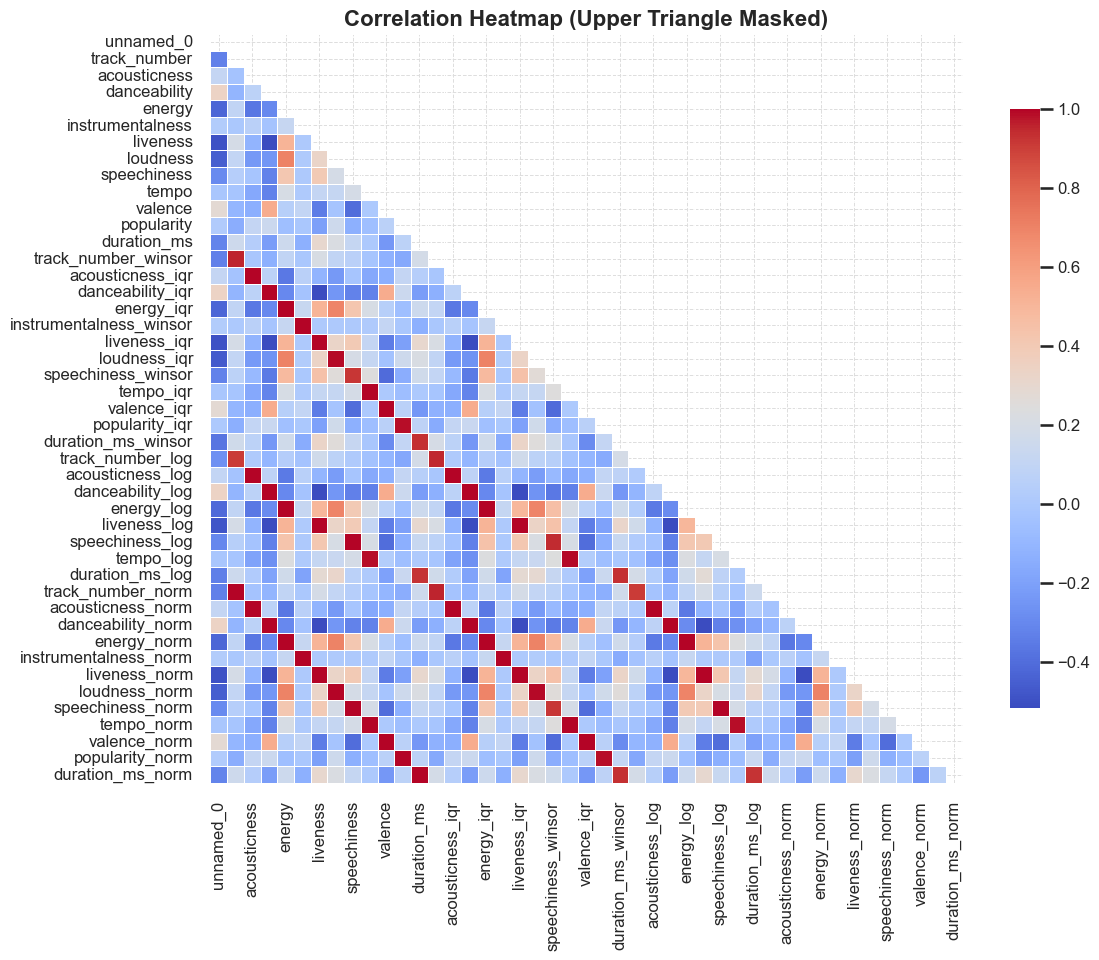

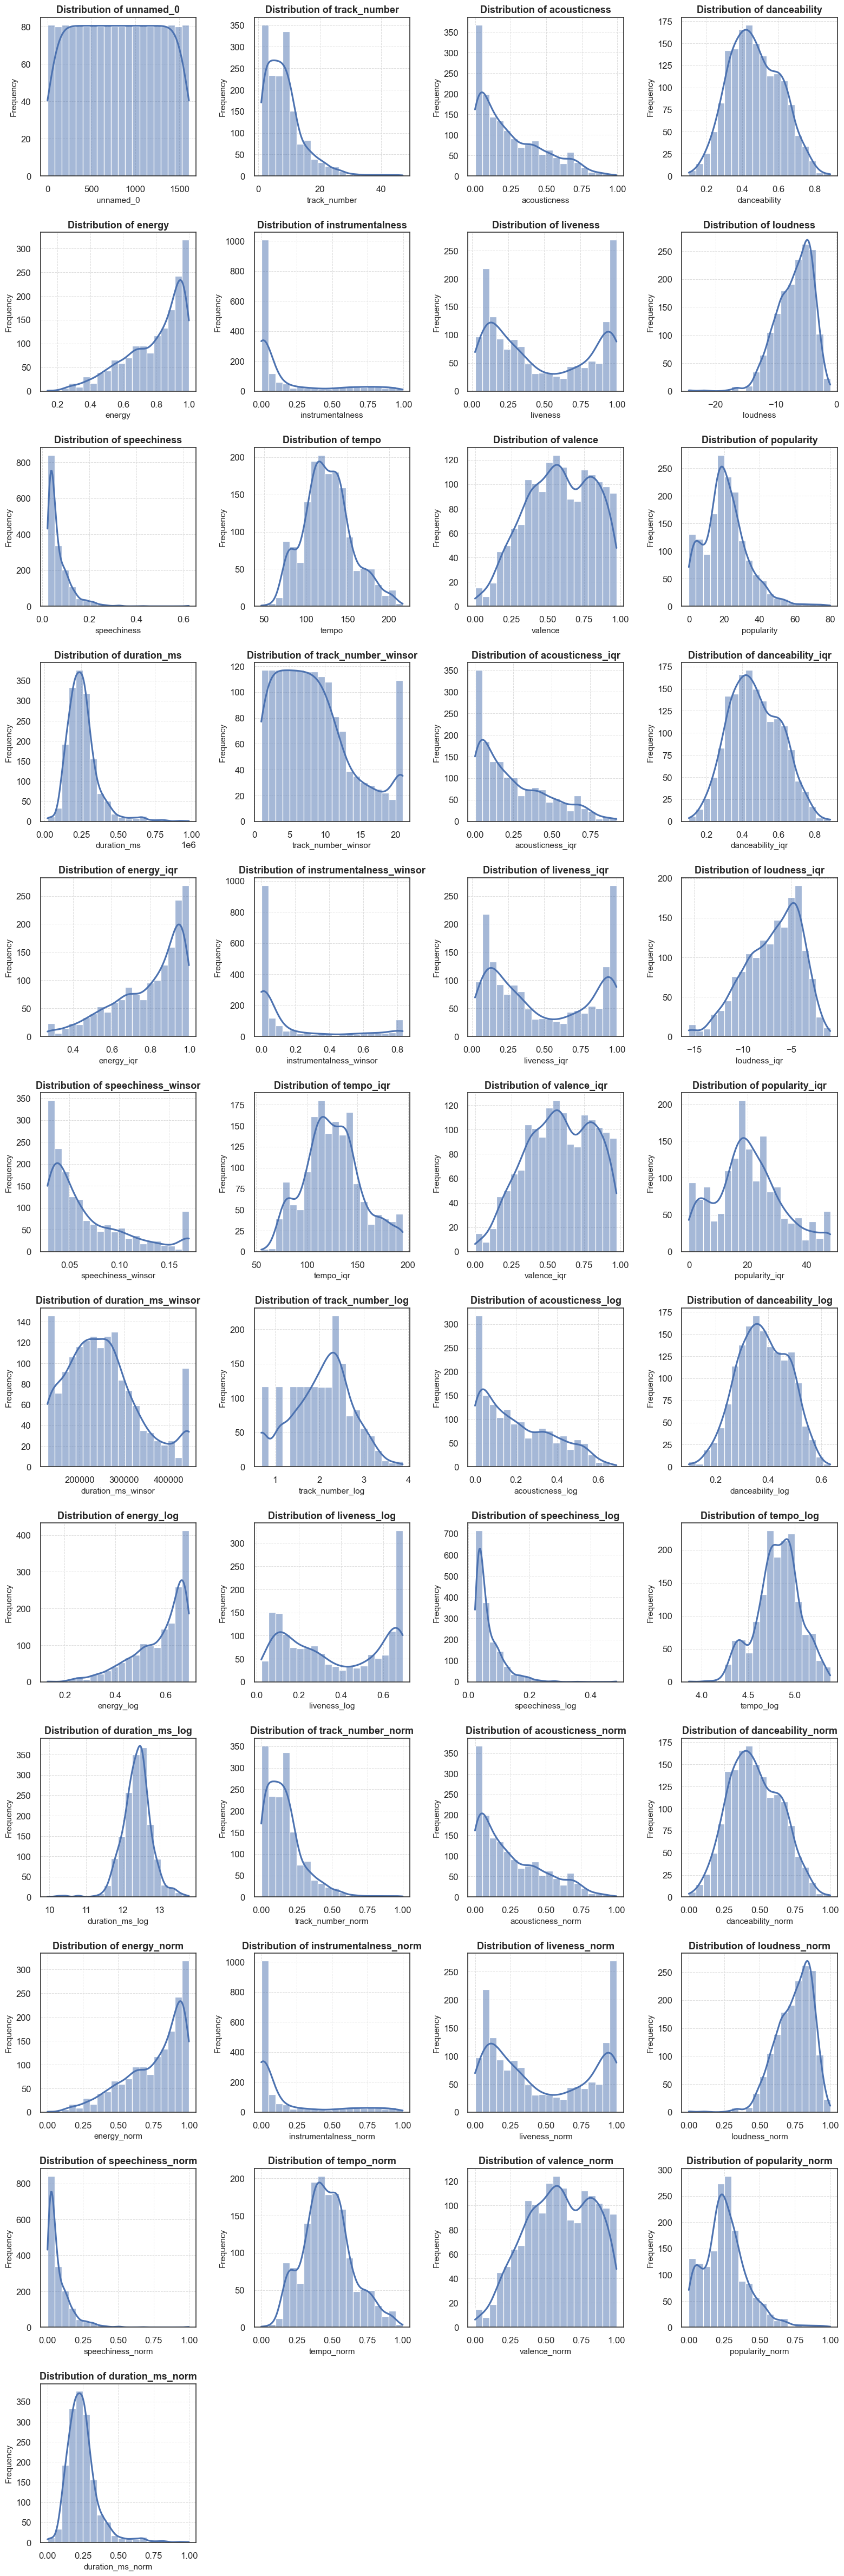

Skipping 'name' — high cardinality (954 unique values)
Skipping 'album' — high cardinality (90 unique values)
Skipping 'release_date' — high cardinality (57 unique values)
Skipping 'id' — high cardinality (1610 unique values)
Skipping 'uri' — high cardinality (1610 unique values)


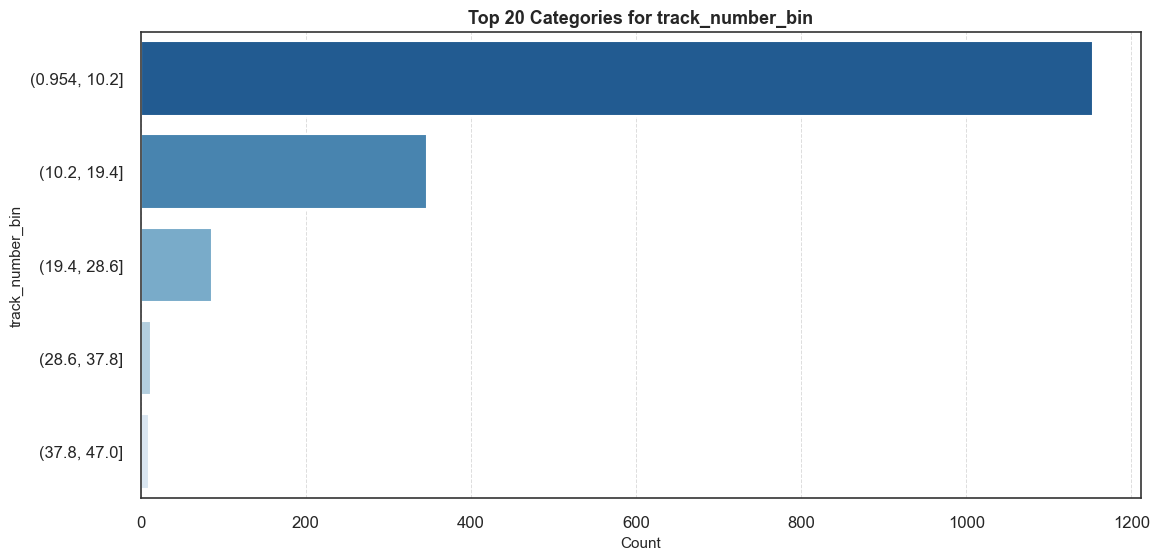

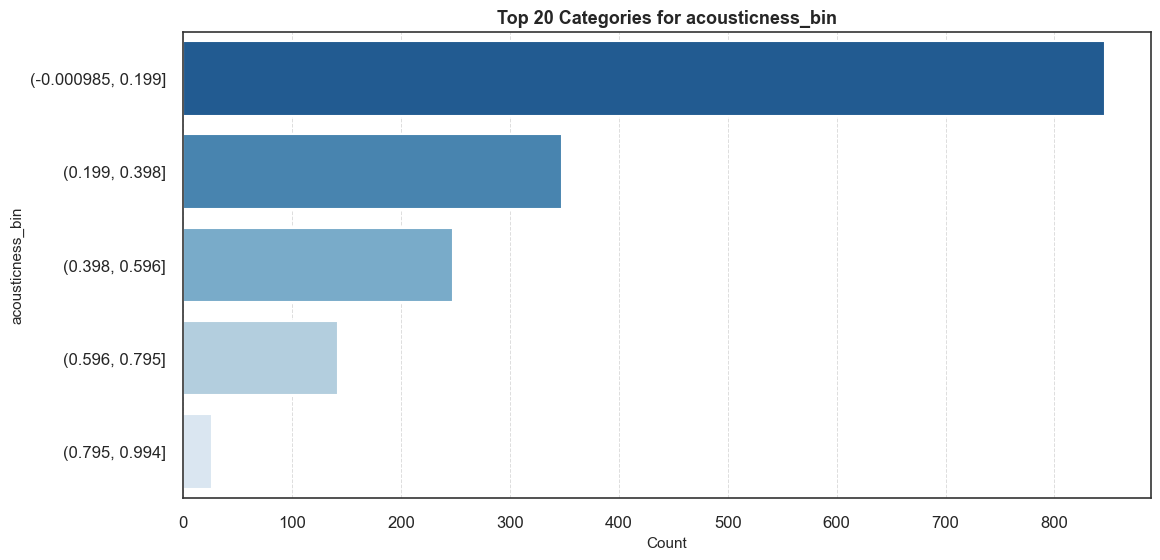

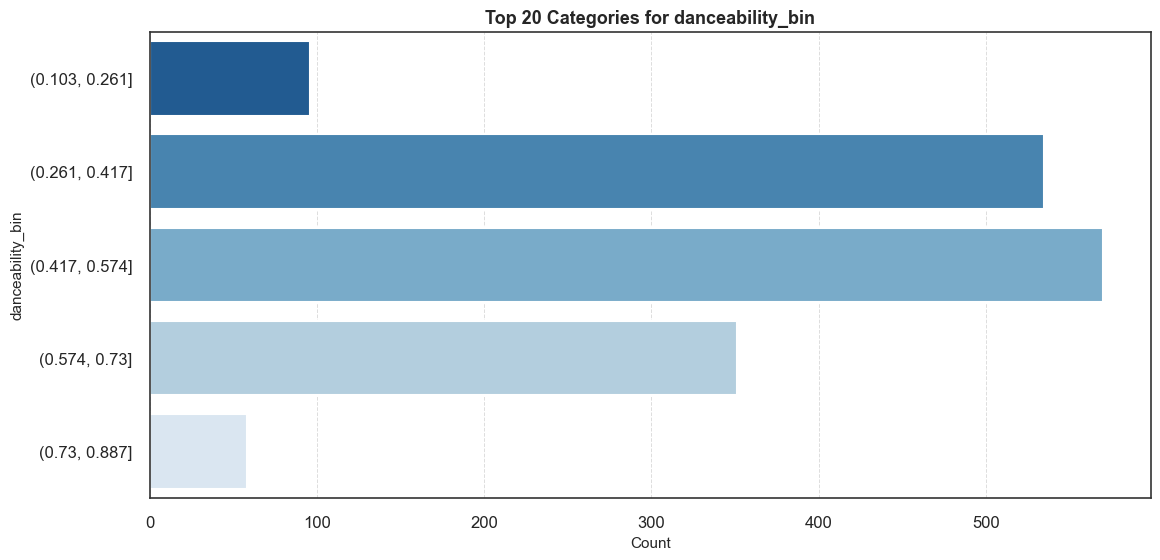

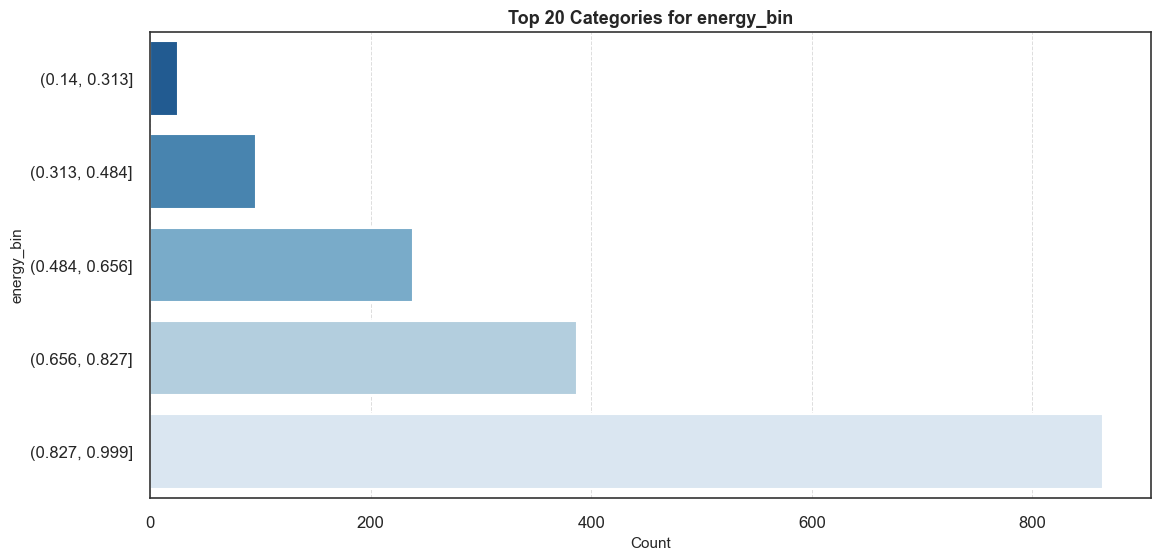

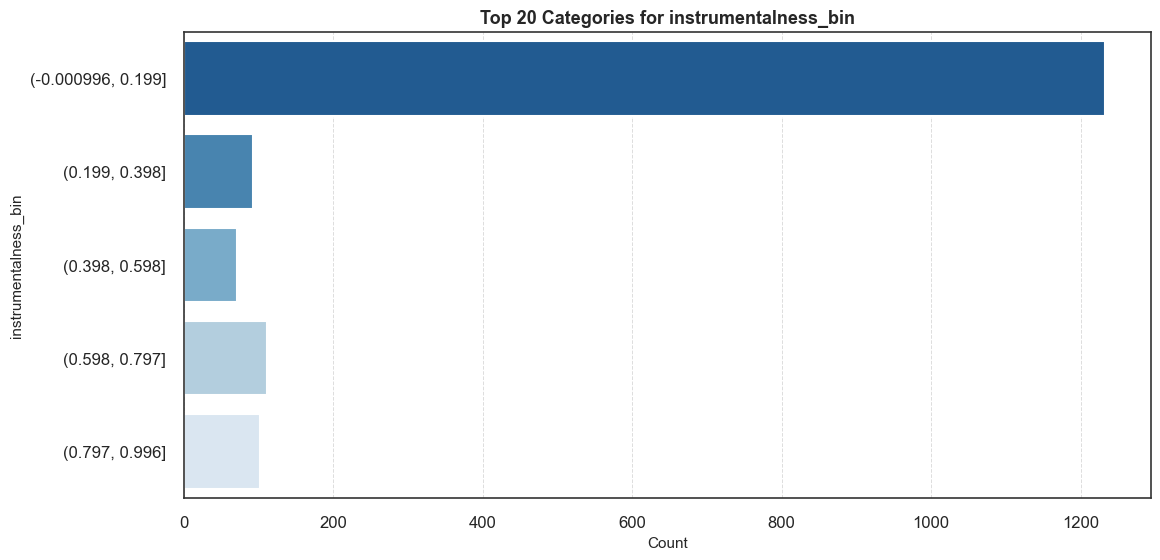

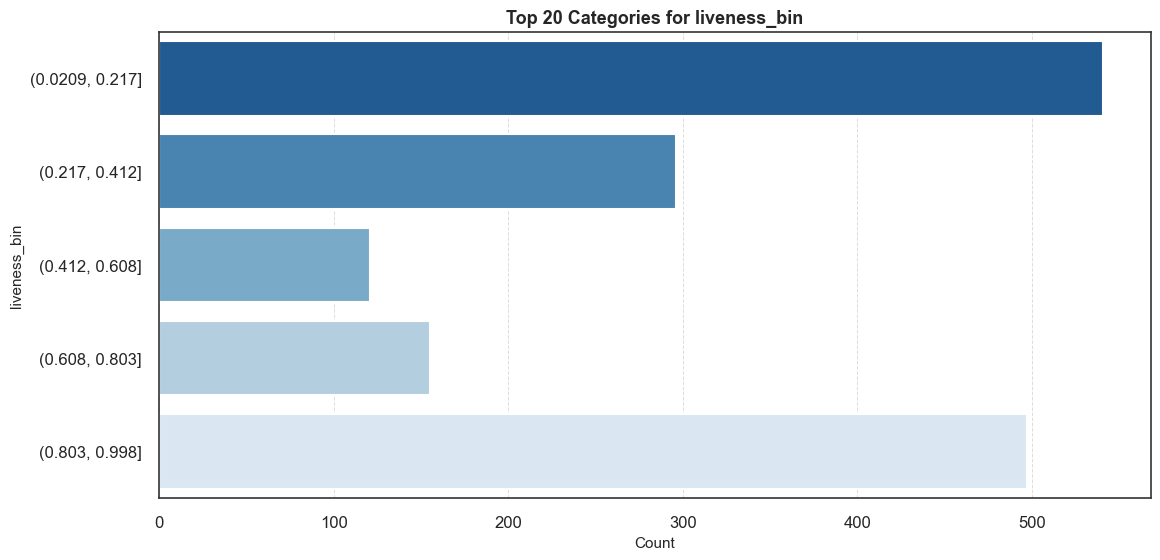

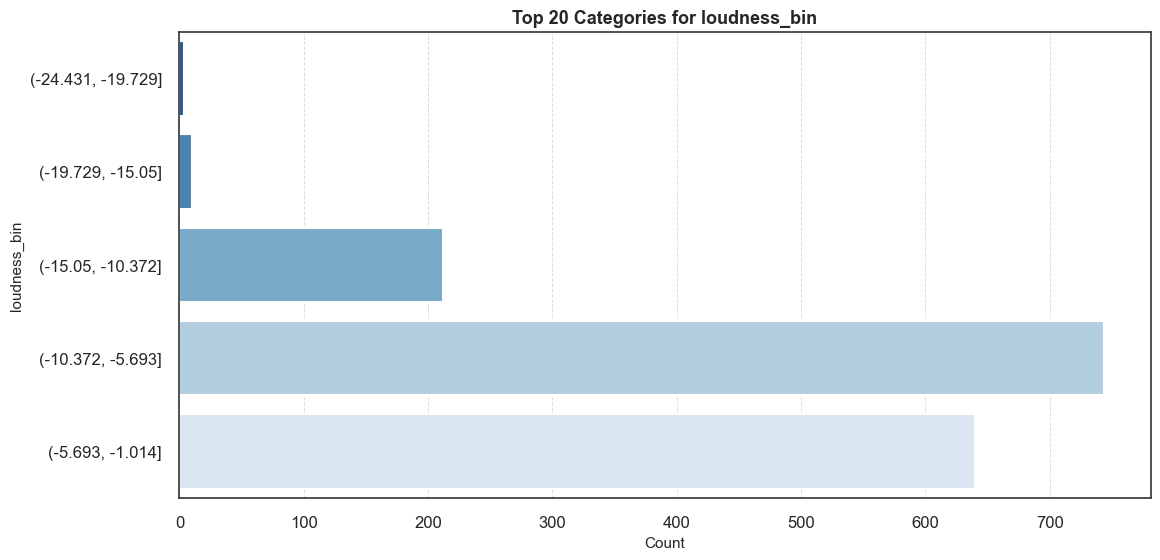

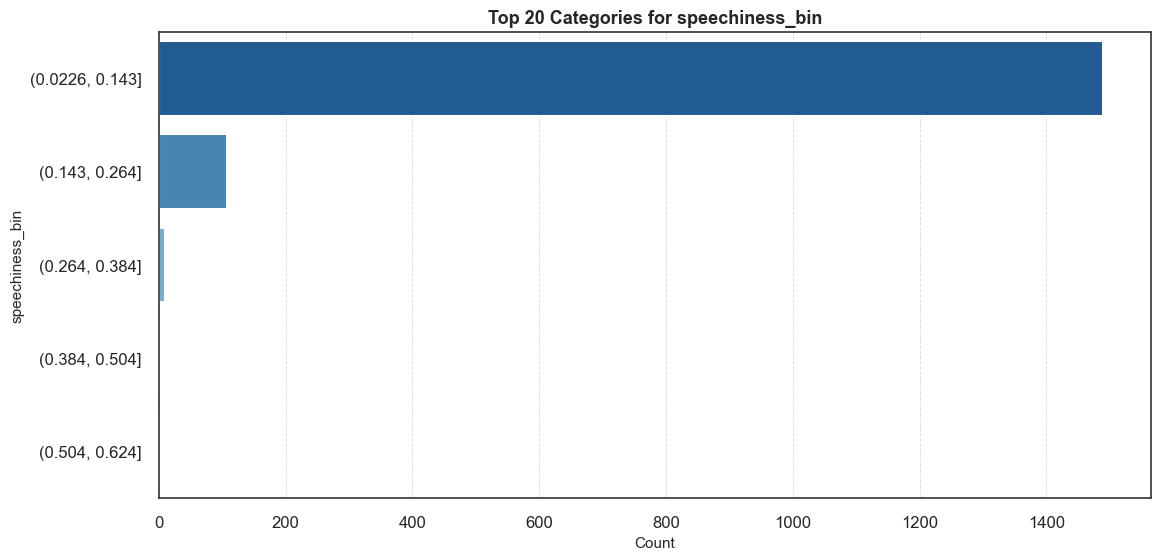

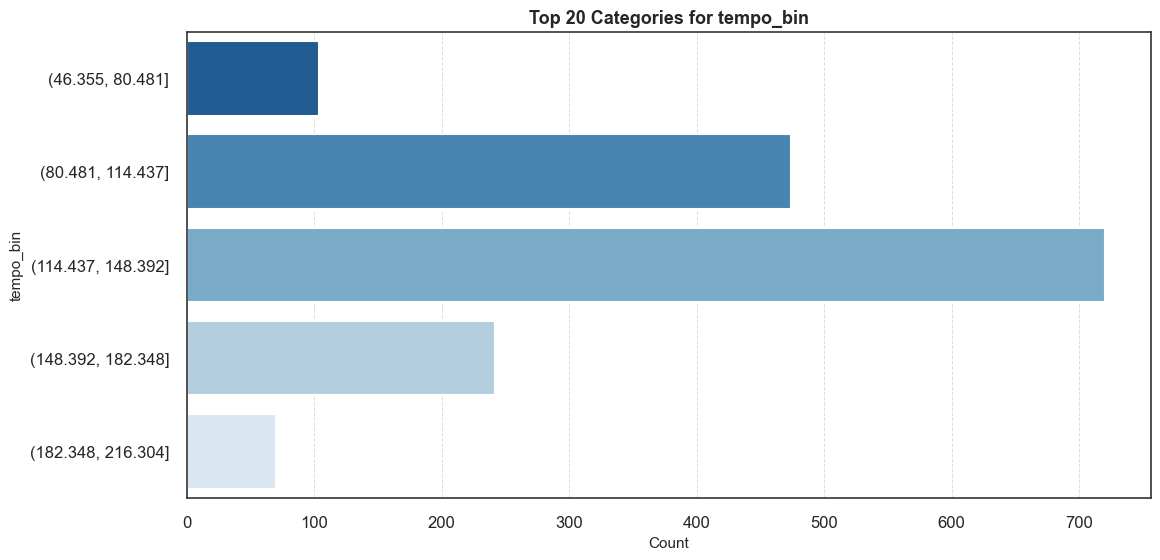

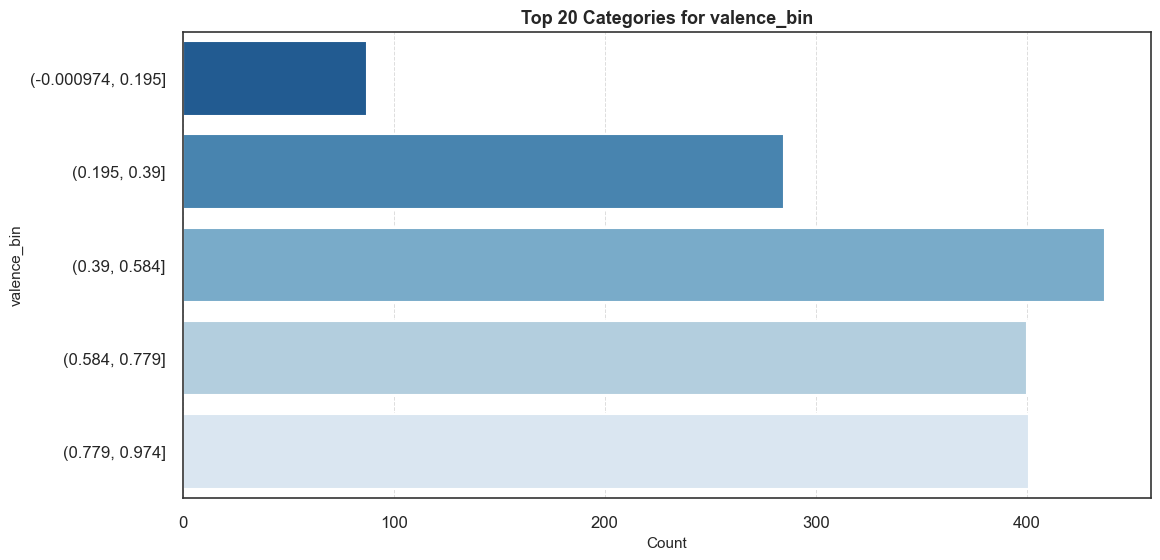

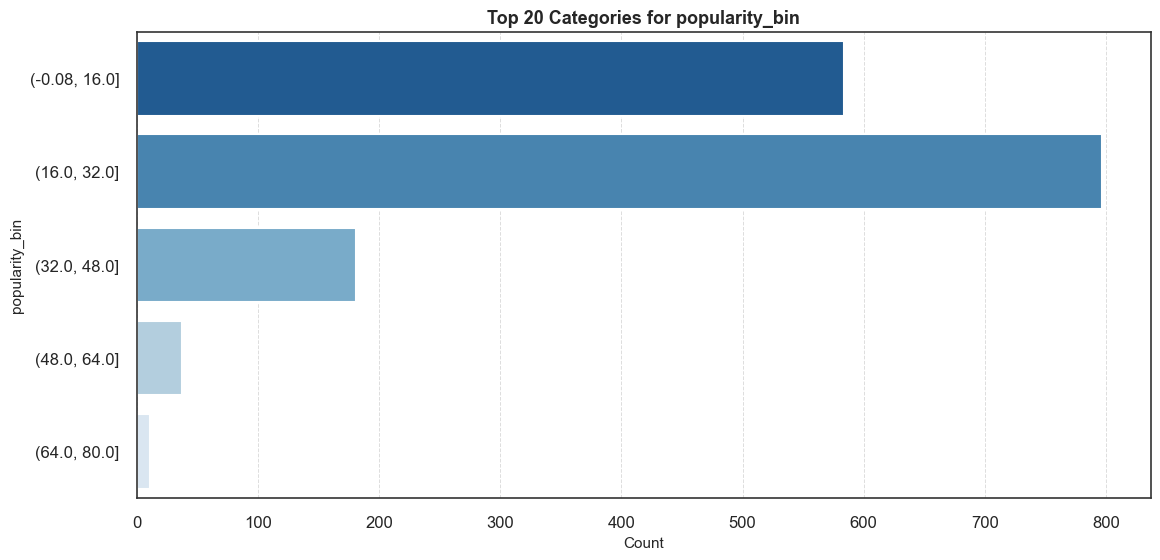

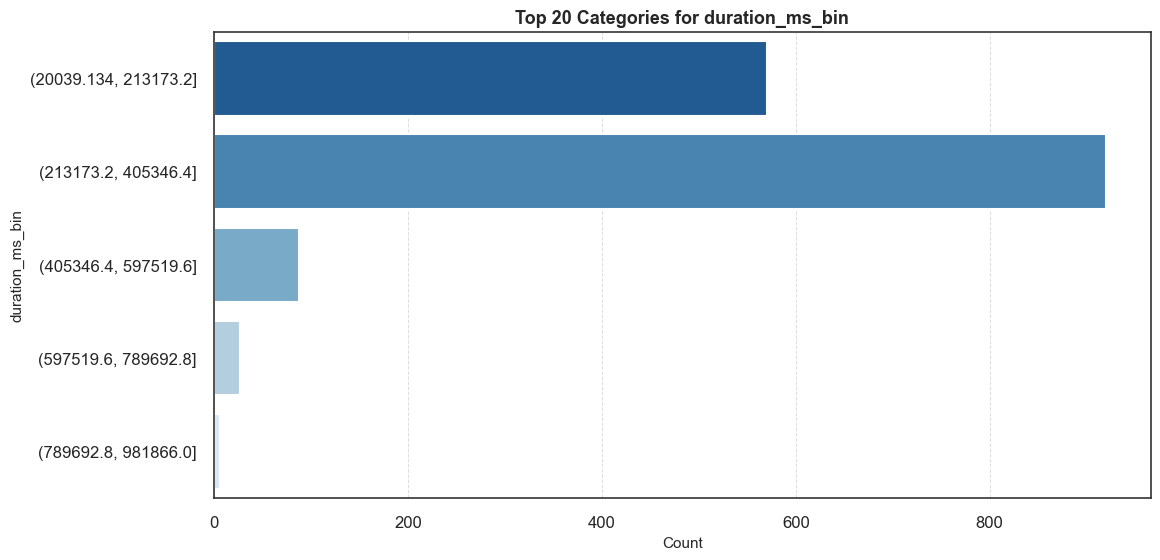


EDA Pipeline Complete.



In [28]:
class UniversalEDA:

    # ---------------------------------------------------------
    # MASTER RUNNER
    # ---------------------------------------------------------
    @staticmethod
    def run(df_processed, target=None):
        print("\n==============================")
        print("📊 UNIVERSAL AUTOMATED EDA")
        print("==============================\n")

        UniversalEDA.basic_info(df_processed)
        UniversalEDA.correlation_heatmap(df_processed)
        UniversalEDA.numeric_distributions(df_processed)
        UniversalEDA.categorical_distributions(df_processed)

        if target and target in df_processed.columns:
            UniversalEDA.target_distribution(df_processed, target)

        print("\nEDA Pipeline Complete.\n")

    # ---------------------------------------------------------
    # BASIC INFO
    # ---------------------------------------------------------
    @staticmethod
    def basic_info(df_processed):
        print("\n--- BASIC DATAFRAME INFO ---")
        print(df_processed.info())
        print("\n--- DESCRIPTIVE STATISTICS ---")
        print(df_processed.describe(include='all').transpose().to_string())

    # ---------------------------------------------------------
    # CORRELATION HEATMAP (STANDARDIZED)
    # ---------------------------------------------------------
    @staticmethod
    def correlation_heatmap(df_processed, figsize=(12,10), cmap='coolwarm', annot=False):
        numeric_df = df_processed.select_dtypes(include='number')

        if numeric_df.empty:
            print("No numeric columns found for correlation heatmap.")
            return

        corr = numeric_df.corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))

        plt.figure(figsize=figsize)
        sns.heatmap(
            corr,
            mask=mask,
            cmap=cmap,
            annot=annot,
            fmt=".2f",
            linewidths=0.5,
            cbar_kws={"shrink": 0.8}
        )
        plt.title("Correlation Heatmap (Upper Triangle Masked)", fontsize=16)
        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------
    # NUMERIC DISTRIBUTIONS (STANDARDIZED)
    # ---------------------------------------------------------
    @staticmethod
    def numeric_distributions(df_processed):
        numeric_cols = df_processed.select_dtypes(include='number').columns

        if numeric_cols.empty:
            print("No numeric columns found for numeric distribution plots.")
            return

        n = len(numeric_cols)
        rows = math.ceil(n / 4)

        fig, axes = plt.subplots(rows, 4, figsize=(16, rows * 4))
        axes = axes.flatten()

        for ax, col in zip(axes, numeric_cols):
            sns.histplot(df_processed[col], bins=20, kde=True, ax=ax)
            ax.set_title(f"Distribution of {col}")
            ax.set_xlabel(col)
            ax.set_ylabel("Frequency")

        for ax in axes[n:]:
            ax.set_visible(False)

        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------
    # CATEGORICAL DISTRIBUTIONS (STANDARDIZED)
    # ---------------------------------------------------------
    @staticmethod
    def categorical_distributions(df, top_n=20, max_unique=30):
        cat_cols = df.select_dtypes(include=['object', 'category']).columns

        if len(cat_cols) == 0:
            print("No categorical columns found.")
            return

        for col in cat_cols:

            # Skip high-cardinality columns
            if df[col].nunique() > max_unique:
                print(f"Skipping '{col}' — high cardinality ({df[col].nunique()} unique values)")
                continue

            counts = df[col].value_counts().head(top_n)

            plt.figure(figsize=(12, 6))
            sns.barplot(
                y=counts.index,     
                x=counts.values,
                palette="Blues_r"
            )
            plt.title(f"Top {top_n} Categories for {col}")
            plt.xlabel("Count")
            plt.ylabel(col)
            plt.tight_layout()
            plt.show()


    # ---------------------------------------------------------
    # TARGET VARIABLE DISTRIBUTION (STANDARDIZED)
    # ---------------------------------------------------------
    @staticmethod
    def target_distribution(df_processed, target):
        print(f"\n--- TARGET VARIABLE: {target} ---")
        print(df_processed[target].value_counts())

        plt.figure(figsize=(8,4))
        sns.histplot(df_processed[target], kde=True)
        plt.title(f"Distribution of {target}")
        plt.xlabel(target)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

# choose how to run the pipeline
UniversalEDA.run(df_processed)
#UniversalEDA.run(df_processed, target="turnover")

## 4. Quick Structural Overview

In [ ]:
# Quick Structural Overview. Incorporated correctly in the pipeline above.

# Inspecting the first few rows of the DataFrame
print(f'Head:\n{df.head().to_string(index=False)}\n')

# Displaying the last few rows of the DataFrame
print(f'Tail:\n{df.tail().to_string(index=False)}\n')

# Providing information about the DataFrame, including data types and non-null counts
print(f'Info:\n{df.info()}\n')

# Displaying descriptive statistics of the DataFrame, such as mean, std, min, max, and so on.
print(f'Describe:\n{df.describe().to_string(index=True)}\n')

# Displaying datatypes of the columns
print(f'Dtypes:\n{df.dtypes}\n')

print(f'Shape: {df.shape}\n')


---
## 5. Data Wrangling

### 5.1 Data Type fixes

In [ ]:
# TODO: Fix any columns with wrong data types. Incorporated correctly in the pipeline above. From classroom instructions, we can use pd.to_numeric with errors='coerce' to convert columns that should be numeric but have some non-numeric values.

# Automatically clean column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
      .str.replace('[^a-zA-Z0-9_]', '', regex=True)
)

# Convert all string-like columns (object or string dtype) to category
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].astype(str).str.strip().astype('category')

df.info()

### 5.2 Missing Value Check

In [ ]:
# Check missing values. Incorporated correctly in the pipeline above.
missing = df.isna().sum()
missing_pct = (df.isna().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing Values'] > 0])

# --- Handle missing values ---
# TODO:
# Option A — Drop rows where a critical column is null:
# df.dropna(subset=['column_name'], inplace=True)

# Option B — Fill numeric columns with median:
# df.fillna(df.median(numeric_only=True), inplace=True)

# Option C — Fill by group (e.g., fill Income by Education + Marital Status group)

# Option D — Use an imputation model (e.g., KNNImputer, IterativeImputer, SimpleImputer with strategy='median' or 'most_frequent')

**📝 Note:** *(Explain your choice — why drop vs fill? What risk does each carry for this dataset?)*

### 5.3 removing duplicates

In [ ]:
# Remove duplicate rows. Incorporated correctly in the pipeline above.
df = df.drop_duplicates()

# Verify the result
df.shape

### 5.3 handling outliers

In [ ]:
# Identify numeric columns only. Hybrid between IQR capping and winsorization. Incorporated correctly in the pipeline above. 
num_cols = df.select_dtypes(include=[np.number]).columns

# Function to cap outliers using IQR
# This block of code identifies numeric columns in the dataframe and defines a function to cap outliers 
# using the Interquartile Range (IQR) method. The function calculates the lower and upper bounds for each 
# numeric column and caps values outside these bounds. Finally, it applies the function to the dataframe 
# to cap outliers in all numeric columns.
def cap_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        # Cap values
        df[col] = np.where(df[col] < lower, lower,
                           np.where(df[col] > upper, upper, df[col]))
    return df


df = cap_outliers(df, num_cols)

### 5.3 renaming columns

In [ ]:
# rename columns where applicable
# Rename individually (You can rename as many or as few as you want.)
df = df.rename(columns={
    'satisfaction_level': 'satisfaction',
    'last_evaluation': 'evaluation',
    'average_montly_hours': 'avg_monthly_hours',
    'time_spend_company': 'years_at_company'
})

# rename all at once (Just make sure the list length matches the number of columns.)
df.columns = [
    'satisfaction', 'evaluation', 'num_projects', 'avg_monthly_hours',
    'years_at_company', 'work_accident', 'left', 'promotion_5yrs',
    'department', 'salary'
]
df.head()

### 5.3 handling negative values

In [ ]:
# Negative Values. Incorporated correctly in the pipeline above. From classroom instructions, we can use pd.to_numeric with errors='coerce' to convert columns that should be numeric but have some non-numeric values, and then handle negative values as needed.
# treat the negative values in the 'income' column as missing and fill them with the median income
df['income'] = df['income'].apply(lambda x: np.nan if x < 0 else x)
df['income'] = df['income'].fillna(df['income'].median()).astype('float32')
print(df.info())
print(df.describe())
df.head(3)

### 5.3 merging/joining datasets

In [ ]:
# merge/join datasets. Incorporated correctly in the pipeline above. This code merges two DataFrames, df1 and df2, on a common key column named 'Key' using a left join. The resulting DataFrame, df1_df2, will contain all rows from df1 and the matching rows from df2 based on the 'Key' column. If there are no matches in df2 for any row in df1, the resulting columns from df2 will have NaN values.
df1_df2 = pd.merge(df1, df2, on='Key', how='left')

### 5.3.2 User/Item Matrix

A **User-Item Matrix** is a table where:
- Each **row** = one user
- Each **column** = one movie title
- Each **cell** = the rating that user gave that movie (`NaN` if not rated)

Use `pandas.pivot_table` with `index='userId'`, `columns='title'`, `values='rating'`.

In [ ]:
# Build the User-Item Matrix using pivot_table
user_item_matrix = movie_ratings.pivot_table(index='userId', columns='title', values='rating')

print(f'Matrix shape: {user_item_matrix.shape}  ->  (users x movies)')
user_item_matrix.head()

### 5.4 Feature Engineering *(if applicable)*

In [ ]:
# TODO: Create any derived columns your analysis needs

print(df.shape)
print(df.info())
df.head()

*Insight
>

### 5.5 GroupBy — Chunking & Aggregation

In [ ]:
# TODO: Use GroupBy to aggregate data by a meaningful dimension. (Categorical vs numerical features)


**📝 Note:** *(What does this grouping reveal? Is there a natural chunking dimension in this dataset — time, state, category?)*

---
## 6. Quick EDA 

### Descriptive Statistical Analysis
### 6.1 Summary Statistics

In [ ]:
# Run describe() on your key numeric columns. Incorporated correctly in the pipeline above. This code selects all numeric columns from the DataFrame df and then applies the describe() method to those columns, which provides summary statistics such as count, mean, standard deviation, minimum, 25th percentile, median (50th percentile), 75th percentile, and maximum for each numeric column.
# Select numeric columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Run describe() on numeric columns
df[num_cols].describe()

*Observation
>

In [ ]:
# compute mean, median, mode, std for each numeric column. Incorporated correctly in the pipeline above. This code computes the mean, median, mode, and standard deviation for each numeric column in the DataFrame df. It first selects the numeric columns, then calculates each statistic and combines them into a summary table called stats_summary.
# Select numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns

# Compute statistics
means = df[num_cols].mean()
medians = df[num_cols].median()
modes = df[num_cols].mode().iloc[0]   # mode() returns a DataFrame
stds = df[num_cols].std()

# Combine into a single summary table
stats_summary = pd.DataFrame({
    'mean': means,
    'median': medians,
    'mode': modes,
    'std': stds
})

stats_summary

**📝 Insight:** *(What does the spread tell you? Is mean ≈ median (symmetric) or far apart (skewed)?)*

### 6.2 Correlation Heatmap

In [ ]:
# Correlation Heatmap. Incorporated correctly in the pipeline above. This function generates a correlation heatmap for the numeric columns in the DataFrame df. It computes the correlation matrix, creates a mask to display only the upper triangle of the matrix (to avoid redundancy), and then plots the heatmap using Seaborn. The heatmap will show the correlation coefficients between pairs of numeric features, with annotations and a specified color map.
def correlation_heatmap_upper(df, figsize=(10,8), cmap='coolwarm', annot=True):
    """
    Generates a clean upper‑triangle masked correlation heatmap.
    Removes duplicate correlations and diagonal values.
    """

    # Select numeric columns
    numeric_df = df.select_dtypes(include='number')

    if numeric_df.empty:
        print("No numeric columns found in the DataFrame.")
        return

    # Compute correlation matrix
    corr = numeric_df.corr()

    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # Plot heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(
        corr,
        mask=mask,
        cmap=cmap,
        annot=annot,
        fmt=".2f",
        linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )

    plt.title("Correlation Heatmap (Upper Triangle Masked)", fontsize=16, pad=12)
    plt.tight_layout()
    plt.show()

    #return corr
correlation_heatmap_upper(df, figsize=(12,10), annot=False)


**Your observation:** 

> Write here...

### 6.3 Distribution of target variable

In [ ]:
# --- Distribution plot of Target Variable ---. Incorporated correctly in the pipeline above. This code snippet calculates the value counts of the 'Target Variable' column in the DataFrame df and then creates a distribution plot (histogram with KDE) for that column using Seaborn. The plot will show the frequency distribution of the target variable, along with a kernel density estimate to visualize the underlying distribution shape.

# Distribution of the target variable

df['Target Variable'].value_counts()

sns.displot(df['Target Variable'], kde=True)
plt.title('Distribution of Target Variable')
plt.xlabel('Target Variable')
plt.ylabel('Frequency')
plt.show()

### 6.4 Histogram of all numerical features

In [ ]:
# Plot the histogram of all numerical features
# Identify numeric columns
numeric_cols = df.select_dtypes(include='number').columns

# Create a compact 4x4 grid of histograms for numeric features
fig, axes = plt.subplots(4, 4, figsize=(13, 13))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], bins=15, kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

# Hide unused axes if fewer than 16 numeric columns
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

**Observation**
>

### 6.5 Bar or Box plots for all categorical features

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math

def plotly_turnover_rate_dashboard(df, target_col='turnover'):
    # ---------------------------------------------------------
    # 1. Identify categorical columns
    # ---------------------------------------------------------
    categorical_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()
    total_plots = len(categorical_cols)

    # ---------------------------------------------------------
    # 2. Add 1 extra plot for number_project
    # ---------------------------------------------------------
    total_plots += 1   # reserve first cell for project-count plot

    # Auto grid size (4 columns max)
    cols = 4
    rows = math.ceil(total_plots / cols)

    # ---------------------------------------------------------
    # 3. Create subplots with WRAPPED TITLE for first plot
    # ---------------------------------------------------------
    fig = make_subplots(
        rows=rows,
        cols=cols,
        subplot_titles=[
            "Employee Count by Project Load<br>(Left vs Stayed)"
        ] + [f"Turnover Rate by {col}" for col in categorical_cols],
        horizontal_spacing=0.07,
        vertical_spacing=0.12
    )

    # ---------------------------------------------------------
    # 4. FIRST PLOT: Stayed vs Left + Turnover Rate for Left
    # ---------------------------------------------------------
    proj_grouped = (
        df.groupby(['number_project', target_col])
        .size()
        .reset_index(name='count')
    )

    # Pivot so counts align correctly
    proj_pivot = proj_grouped.pivot(
        index='number_project',
        columns=target_col,
        values='count'
    ).fillna(0)

    proj_pivot.columns = ['Stayed', 'Left']

    # Compute turnover rate for LEFT
    proj_pivot['turnover_rate'] = proj_pivot['Left'] / (proj_pivot['Left'] + proj_pivot['Stayed'])

    # Stayed trace
    fig.add_trace(
        go.Bar(
            x=proj_pivot.index,
            y=proj_pivot['Stayed'],
            marker_color="#4C78A8",
            hovertemplate=(
                "<b>Projects:</b> %{x}"
                "<br>Employees Stayed: %{y}"
                "<extra></extra>"
            ),
            showlegend=False
        ),
        row=1,
        col=1
    )

    # Left trace (with turnover rate)
    fig.add_trace(
        go.Bar(
            x=proj_pivot.index,
            y=proj_pivot['Left'],
            marker_color="#F58518",
            customdata=proj_pivot['turnover_rate'],
            hovertemplate=(
                "<b>Projects:</b> %{x}"
                "<br>Employees Left: %{y}"
                "<br>Turnover Rate (Left): %{customdata:.2f}"
                "<extra></extra>"
            ),
            showlegend=False
        ),
        row=1,
        col=1
    )

    # ---------------------------------------------------------
    # 5. REMAINING PLOTS: Turnover Rate by Categorical Feature
    # ---------------------------------------------------------
    r, c = 1, 2   # start after the first plot

    for col in categorical_cols:

        grouped = (
            df.groupby(col)[target_col]
            .mean()
            .reset_index(name='turnover_rate')
        )

        fig.add_trace(
            go.Bar(
                x=grouped[col],
                y=grouped['turnover_rate'],
                marker_color="#4C78A8",
                hovertemplate=(
                    f"<b>{col}</b>: %{{x}}"
                    "<br>Turnover Rate: %{y:.2f}"
                    "<extra></extra>"
                ),
                showlegend=False
            ),
            row=r,
            col=c
        )

        # Move to next subplot cell
        c += 1
        if c > cols:
            c = 1
            r += 1

    # ---------------------------------------------------------
    # 6. Layout styling
    # ---------------------------------------------------------
    fig.update_layout(
        height=350 * rows,
        width=1400,
        autosize=False,
        title={
            "text": "Interactive Turnover Dashboard<br>(Rates + Project Load)",
            "x": 0.5,
            "xanchor": "center",
            "yanchor": "top",
            "font": {"size": 26}
        },
        showlegend=False,   # <-- legend removed globally
        template="plotly_white",
        margin=dict(l=40, r=40, t=120, b=40),
        barmode="group"
    )

    fig.update_annotations(font_size=12)
    fig.show()

plotly_turnover_rate_dashboard(df)

**📝 Insight:** *(Are there outliers? Which direction? Do they make business sense or are they data errors?)*

### 6.6 Catplots - Chunking and aggregation

In [ ]:
# Catplots - Chunking and aggregation
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np
# import scipy.stats as ss

# -----------------------------
#  UNIVERSAL PLOTTING HELPERS
# -----------------------------

def plot_bar(data, x, y, title, ax, palette='Blues', rotate=True, hue=None):
    sns.barplot(data=data, x=x, y=y, hue=hue, palette=palette, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    if rotate:
        ax.tick_params(axis='x', rotation=45)
    if hue:
        ax.legend(title=hue)


def plot_heatmap(pivot, title, ax, cmap='coolwarm'):
    sns.heatmap(pivot, annot=True, cmap=cmap, fmt=".2f", linewidths=0.5, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(pivot.columns.name)
    ax.set_ylabel(pivot.index.name)


# -----------------------------
#  INDIVIDUAL GROUPBY PLOTS
# -----------------------------

def avg_satisfaction_by_department(df, ax):
    grouped = df.groupby('department')['satisfaction_level'].mean().reset_index()
    plot_bar(grouped, 'department', 'satisfaction_level', "Avg Satisfaction by Department", ax)
    return grouped


def turnover_by_department_salary(df, ax):
    grouped = (
        df.groupby(['department', 'salary'])['turnover']
        .mean()
        .reset_index()
    )

    plot_bar(
        data=grouped,
        x='department',
        y='turnover',
        hue='salary',
        title="Turnover Rate by Department × Salary",
        ax=ax
    )

    return grouped


def workload_summary(df, ax):
    grouped = df.groupby('department').agg({
        'average_monthly_hours': ['mean', 'min', 'max'],
        'number_project': ['mean', 'median'],
        'satisfaction_level': 'mean'
    })
    grouped.columns = ['_'.join(col) for col in grouped.columns]
    data = grouped.reset_index()
    plot_bar(data, 'department', 'average_monthly_hours_mean', "Avg Monthly Hours by Department", ax)
    return grouped


def satisfaction_by_tenure(df, ax):
    df = df.copy()
    df['tenure_bucket'] = pd.cut(
        df['time_spend_company'],
        bins=[0, 2, 4, 6, 10],
        labels=['0-2', '3-4', '5-6', '7+']
    )
    grouped = df.groupby('tenure_bucket')['satisfaction_level'].mean().reset_index()
    plot_bar(grouped, 'tenure_bucket', 'satisfaction_level', "Satisfaction by Tenure Bucket", ax, rotate=False)
    return grouped


def employee_count_by_department(df, ax):
    grouped = df.groupby('department').size().reset_index(name='count')
    plot_bar(grouped, 'department', 'count', "Employee Count by Department", ax)
    return grouped


def turnover_percentage_by_department(df, ax):
    grouped = (
        df.groupby('department')['turnover']
        .value_counts(normalize=True)
        .mul(100)
        .rename('percentage')
        .reset_index()
        .query('turnover == 1')
    )
    plot_bar(grouped, 'department', 'percentage', "Turnover % by Department", ax)
    return grouped


# -----------------------------
#  FULL DASHBOARD
# -----------------------------

def hr_dashboard(df, figsize=(22, 18)):
    fig, axes = plt.subplots(3, 2, figsize=figsize)
    axes = axes.flatten()

    avg_satisfaction_by_department(df, axes[0])
    turnover_by_department_salary(df, axes[1])
    workload_summary(df, axes[2])
    satisfaction_by_tenure(df, axes[3])
    employee_count_by_department(df, axes[4])
    turnover_percentage_by_department(df, axes[5])

    plt.tight_layout()
    plt.show()

hr_dashboard(df)

**📝 Dashboard Takeaway:**

> Write here...

---
## 7. Key Findings

> Each cell below = one focused question. Lead with the chart, follow with the insight.

### 7.1 Highest & Lowest Performing Groups/Segments

In [ ]:
# TODO: Identify top and bottom performing group/state/category

# Your code here:


**📝 Insight:** *(Which group/state is highest? Lowest? By how much? What might explain the gap?)*

---
## 8. Recommendations

> Be specific. Every recommendation should connect back to a finding above.  
> Avoid vague statements like "improve sales" — say *where*, *how*, and *why*.

| # | Finding | Recommendation | Priority |
|---|---|---|---|
| 1 | *(e.g., ABC has 40% lower revenue than XYZ)* | *(e.g., Launch targeted discounts and awareness campaigns in ABC stores in Q1)* | High |
| 2 | | | |
| 3 | | | |
| 4 | | | |

---
## 9. Conclusion

> 4–6 sentences max. Answer the original business question stated in Section 1.  
> Do not introduce new findings here — only summarize.

*(Write your conclusion here.)*

## 10. Future Scope(Optional)

  Something you think as an extra steps or advanced analysis that can be done.

---
## Supervised Learning - Regression Modeling


In [ ]:
# --- Features and Target ---
X = df.drop(columns=['target_variable'])  # Drop target from features
y = df['target_variable']  # Target variable

# --- Step 1: Train-test split (80:20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Step 2: Preprocessing (impute missing, scale numeric, encode categorical) ---
numeric_features = X.select_dtypes(include=['int64','float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ]
)

# --- Step 3: Define models ---
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(random_state=42),
    "Ridge": Ridge(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

# --- Step 4: Hyperparameter tuning with RandomizedSearchCV ---
param_distributions = {
    "Lasso": {"clf__alpha": np.logspace(-4, 4, 50)},
    "Ridge": {"clf__alpha": np.logspace(-4, 4, 50)},
    "Decision Tree": {
        "clf__max_depth": [None, 5, 10, 20, 50],
        "clf__min_samples_split": [2, 5, 10, 20],
        "clf__min_samples_leaf": [1, 2, 5, 10]
    }
}

results = []

for name, clf in models.items():
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('clf', clf)
    ])
    
    if name in param_distributions:
        search = RandomizedSearchCV(
            pipeline,
            param_distributions[name],
            n_iter=20,
            scoring='r2',
            cv=5,
            random_state=42,
            n_jobs=-1
        )
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
    else:
        best_model = pipeline.fit(X_train, y_train)
    
    y_pred = best_model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append([name, r2, rmse])
    print(f"{name} → R²: {r2:.4f}, RMSE: {rmse:.4f}")

# --- Step 5: Results DataFrame ---
results_df = pd.DataFrame(results, columns=["Model", "R²", "RMSE"])
print("\nModel Comparison:\n", results_df)

# --- Step 6: Identify best model ---
best_model_name = results_df.loc[results_df['R²'].idxmax(), 'Model']
print(f"\nBest Model based on R²: {best_model_name}")


**Final reflection:** *(Which model would you recommend for this problem and why?)*

> Write here... Based on the model comparison, the Decision Tree is the recommended choice because it delivers substantially stronger predictive performance than all linear models, achieving an R² of 0.8639 and an RMSE of 237.18 — nearly doubling the explained variance and cutting prediction error almost in half compared to Linear Regression, Ridge, and Lasso. This dataset contains clear nonlinear patterns driven by hourly usage cycles, weather conditions, and seasonal effects, which linear models cannot capture without extensive feature engineering. The Decision Tree naturally models these nonlinear relationships and interactions, allowing it to fit the structure of the bike rental data far more effectively. While ensemble methods like Random Forest or Gradient Boosting could further improve generalization, the Decision Tree is the best-performing model among those evaluated and is therefore the most appropriate recommendation.

## Supervised Learning - Classification models with confusion matrix and AUC for best model.

In [ ]:
# Classification models with confusion matrix and AUC for best model.

# ============================================================
# 1. PREPROCESSING
# ============================================================
def preprocess(df, target_col='turnover'):
    cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
    num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

    if target_col in num_cols:
        num_cols.remove(target_col)

    df_cat = pd.get_dummies(df[cat_cols], drop_first=True)

    scaler = StandardScaler()
    df_num = pd.DataFrame(
        scaler.fit_transform(df[num_cols]),
        columns=num_cols,
        index=df.index
    )

    X = pd.concat([df_num, df_cat], axis=1)
    y = df[target_col]

    return train_test_split(X, y, test_size=0.2, stratify=y, random_state=123)

X_train, X_test, y_train, y_test = preprocess(df)

# ============================================================
# 2. MODELS
# ============================================================
models = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=123),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=123),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=123),
    "Random Forest": RandomForestClassifier(random_state=123),
    "Gradient Boosting": GradientBoostingClassifier(random_state=123),
    "Balanced Random Forest": BalancedRandomForestClassifier(random_state=123, sampling_strategy='auto', replacement=False, bootstrap=True)
}

# ============================================================
# 3. 5-FOLD CV + Smote (NO LEAKAGE via Pipeline) 
# - Use SMOTE with smaller datasets to correct the imbalance
# - Use RandomUnderSampling with large data sets
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
# calculate cross-validation scores and store ROC curve data, confusion matrices, and classification reports for each model

results = []
roc_data = {}
cm_data = {}
report_data = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('smote', SMOTE(random_state=123)),
        ('model', model)
    ])
    #------------------------------------------------------------------------------------------
    #---------------------added to calculate cross-validation scores to the results (2 secions)
    #------------------------------------------------------------------------------------------
        # --- TRUE CROSS‑VALIDATION SCORES (MEAN ± STD) (Start of updated code) ---
    scoring_metrics = {
        "Accuracy": "accuracy",
        "Precision": "precision",
        "Recall": "recall",
        "F1": "f1",
        "AUC": "roc_auc"
    }

    cv_scores = {}
    for metric_name, metric in scoring_metrics.items():
        scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring=metric)
        cv_scores[metric_name] = (scores.mean(), scores.std())

    # --- CROSS‑VALIDATED PREDICTIONS FOR CONFUSION MATRIX + ROC ---
    y_pred = cross_val_predict(pipeline, X_train, y_train, cv=cv)
    y_prob = cross_val_predict(pipeline, X_train, y_train, cv=cv, method='predict_proba')[:,1]
    #------------------------------------------------------------------------------------------
    #--------------------------------end of updated code---------------------------------------
    #------------------------------------------------------------------------------------------
    
    # original code if the new one does not work:
    #y_pred = cross_val_predict(pipeline, X_train, y_train, cv=cv)
    #y_prob = cross_val_predict(pipeline, X_train, y_train, cv=cv, method='predict_proba')[:,1]

    # Metrics
    acc = accuracy_score(y_train, y_pred)
    f1 = f1_score(y_train, y_pred)
    prec = precision_score(y_train, y_pred)
    rec = recall_score(y_train, y_pred)
    auc_score = roc_auc_score(y_train, y_prob)

    #------------------------------------------------------------------------------------------
    #---------------------added to calculate cross-validation scores to the results------------
    #------------------------------------------------------------------------------------------
    results.append({
    "Model": name,
    "Accuracy": cv_scores["Accuracy"][0],
    "Precision": cv_scores["Precision"][0],
    "Recall": cv_scores["Recall"][0],
    "F1 Score": cv_scores["F1"][0],
    "AUC": cv_scores["AUC"][0],
    "Acc_std": cv_scores["Accuracy"][1],
    "Prec_std": cv_scores["Precision"][1],
    "Rec_std": cv_scores["Recall"][1],
    "F1_std": cv_scores["F1"][1],
    "AUC_std": cv_scores["AUC"][1]
    })
    #------------------------------------------------------------------------------------------
    #--------------------------------end of updated code---------------------------------------
    #------------------------------------------------------------------------------------------

    # original code if the new one does not work:
    #results.append({
    #    "Model": name,
    #    "Accuracy": acc,
    #    "Precision": prec,
    #    "Recall": rec,
    #    "F1 Score": f1,
    #    "AUC": auc_score
    #})

    fpr, tpr, _ = roc_curve(y_train, y_prob)
    roc_data[name] = (fpr, tpr, auc_score)
    cm_data[name] = confusion_matrix(y_train, y_pred)
    report_data[name] = pd.DataFrame(
        classification_report(y_train, y_pred, output_dict=True)
    ).iloc[:-1, :].T

# ============================================================
# 4. DASHBOARD VISUALS
# ============================================================

# ROC curves
plt.figure(figsize=(8,6))
for name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.2f})")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curves (5-Fold CV)")
plt.xlabel('xlabel')
plt.ylabel('ylabel')
plt.legend()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(3,3, figsize=(15,12))
axes = axes.flatten()
for ax, (name, cm) in zip(axes, cm_data.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, display_labels = ["label_1", "label_2"], annot_kws={"fontsize": 12})
    ax.set_title(name)
for i in range(len(cm_data), len(axes)):
    axes[i].axis('off')
plt.show()

# Report heatmaps
fig, axes = plt.subplots(3,3, figsize=(18,12))
axes = axes.flatten()
for ax, (name, rep) in zip(axes, report_data.items()):
    sns.heatmap(rep, annot=True, fmt=".2f", cmap='Blues', ax=ax, annot_kws={"fontsize": 12})
    ax.set_title(name)
for i in range(len(report_data), len(axes)):
    axes[i].axis('off')
plt.show()

# ============================================================
# 5. TRAIN + TEST EVALUATION (REAL PERFORMANCE)
# ============================================================
test_results = []
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('smote', SMOTE(random_state=123)),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:,1]

    test_results.append({
        "Model": name,
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

test_df = pd.DataFrame(test_results)
print("\n===== TEST PERFORMANCE =====\n", test_df)

# ============================================================
# 6. BEST MODEL SELECTION
# ============================================================
filtered = test_df[test_df["Precision"] >= 0.80].copy()
if filtered.empty:
    filtered = test_df.copy()

filtered["Recall_r"] = filtered["Recall"].round(3)

filtered = filtered.sort_values(
    by=["Recall_r","F1","AUC"],
    ascending=False
)

best_model_name = filtered.iloc[0]["Model"]
print("\nBest Model:", best_model_name)

best_model = trained_models[best_model_name]

# ============================================================
# 7. FINAL EVALUATION
# ============================================================
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', display_labels = ["label_1", "label_2"], annot_kws={"fontsize": 12})
plt.title("Test Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

# ============================================================
# 8. RISK ZONES
# ============================================================
risk_df = pd.DataFrame({"turnover_prob": y_prob}, index=X_test.index)

risk_df['risk_zone'] = pd.cut(
    risk_df['turnover_prob'],
    bins=[0,0.2,0.6,0.9,1.01],
    labels=['Safe (Green)','Low-Risk (Yellow)','Medium-Risk (Orange)','High-Risk (Red)'],
)

print("\nRisk Zones:\n", risk_df['risk_zone'].value_counts())

# ============================================================
# 9. METRIC EXPLANATION
# ============================================================
print("\nMetric Choice from Confusion Matrix:")
print(
    "For employee turnover, Recall for the 'left' / positive class is more critical than Precision.\n"
    "Recall answers: 'Of all employees who actually left, how many did we correctly flag?'\n"
    "Missing a true leaver (false negative) is usually more costly than flagging someone who stays."
)

# ============================================================
# 10. RETENTION STRATEGY
# ============================================================
print("\nRetention Strategy Suggestions by Risk Zone:")
print(
    "Safe (Green, <20%): Maintain current conditions, recognition, and growth paths; use as culture carriers.\n"
    "Low-Risk (Yellow, 20–60%): Light-touch check-ins, development opportunities, workload balance.\n"
    "Medium-Risk (Orange, 60–90%): Manager 1:1s, targeted interventions (flexibility, role fit, compensation review).\n"
    "High-Risk (Red, >90%): Immediate, personalized retention plans, HR involvement, internal mobility, and critical pay/role adjustments."
)

# Ensemble Learning (Supervised) - Simple Techniques used in Ensemble Learning

## Ensemble learning - Hard voting + Soft Voting (best for classification modeling)

In [ ]:
# UNIFIED PIPELINE: IMPUTATION → SCALING → SMOTE → MODEL → CV → ROC → SELECTION

# ============================================================
# 1. TRAIN–TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=7
)

# ============================================================
# 2. UNIFIED PIPELINE BUILDER
# ============================================================

def unified_pipeline(model):
    """
    Creates a single sklearn Pipeline that performs:
    - Median imputation
    - Standard scaling
    - SMOTE oversampling
    - Final model
    """
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=7)),
        ('model', model)
    ])

# ============================================================
# 3. DEFINE MODELS (ALL USING THE SAME PIPELINE)
# ============================================================

models = {
    "Logistic Regression": unified_pipeline(LogisticRegression(max_iter=10000, random_state=7)),
    "Decision Tree": unified_pipeline(DecisionTreeClassifier(random_state=7)),
    "SVM": unified_pipeline(SVC(probability=True, random_state=7))
}

# Voting ensembles also use the unified pipelines
models["Hard Voting"] = VotingClassifier(
    estimators=[
        ('lr', models["Logistic Regression"]),
        ('dt', models["Decision Tree"]),
        ('svc', models["SVM"])
    ],
    voting='hard'
)

models["Soft Voting"] = VotingClassifier(
    estimators=[
        ('lr', models["Logistic Regression"]),
        ('dt', models["Decision Tree"]),
        ('svc', models["SVM"])
    ],
    voting='soft'
)

# ============================================================
# 4. CROSS‑VALIDATION + ROC DATA
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

results = []
roc_data = {}

for name, model in models.items():

    # Cross‑validated predictions
    y_pred_cv = cross_val_predict(model, X_train, y_train, cv=cv)
    y_prob_cv = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

    # Metrics
    acc = accuracy_score(y_train, y_pred_cv)
    prec = precision_score(y_train, y_pred_cv)
    rec = recall_score(y_train, y_pred_cv)
    f1 = f1_score(y_train, y_pred_cv)
    auc = roc_auc_score(y_train, y_prob_cv)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "AUC": auc
    })

    # ROC curve data
    fpr, tpr, _ = roc_curve(y_train, y_prob_cv)
    roc_data[name] = (fpr, tpr, auc)

results_df = pd.DataFrame(results)
print("\n===== MODEL COMPARISON (CV) =====\n")
print(results_df)

# ============================================================
# 5. ROC CURVE PLOT FOR ALL MODELS
# ============================================================

plt.figure(figsize=(8, 6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title("ROC Curves (5-Fold CV)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 6. MODEL SELECTION LOGIC (Recall → F1 → AUC)
# ============================================================

filtered = results_df[results_df["Precision"] >= 0.80].copy()
if filtered.empty:
    filtered = results_df.copy()

filtered = filtered.sort_values(
    by=["Recall", "F1 Score", "AUC"],
    ascending=[False, False, False]
)

best_model_name = filtered.iloc[0]["Model"]
print(f"\nBest Model Based on Recall → F1 → AUC: {best_model_name}")

best_model = models[best_model_name]

# ============================================================
# 7. TRAIN BEST MODEL ON FULL TRAINING SET
# ============================================================

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# ============================================================
# 8. FINAL TEST EVALUATION
# ============================================================

print("\n===== TEST SET PERFORMANCE =====\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# ============================================================
# 9. FINAL ROC CURVE (TEST SET)
# ============================================================

fpr_test, tpr_test, _ = roc_curve(y_test, y_prob)
auc_test = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr_test, tpr_test, lw=2, label=f"AUC={auc_test:.2f}")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title(f"ROC Curve - {best_model_name} (Test Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 10. WHY THIS MODEL WAS SELECTED
# ============================================================

print("\n===== WHY THIS MODEL WAS SELECTED =====\n")

bm = filtered.iloc[0]

print(f"Selected Model: {best_model_name}\n")
print("This model was selected using business-driven ranking logic:")
print("1. Recall (highest priority)")
print("2. F1 Score (secondary priority)")
print("3. AUC (tie-breaker)")
print("4. Precision floor (≥ 0.80)\n")

print("Cross-validated performance of the selected model:")
print(f"- Recall:     {bm['Recall']:.3f}")
print(f"- F1 Score:   {bm['F1 Score']:.3f}")
print(f"- Precision:  {bm['Precision']:.3f}")
print(f"- AUC:        {bm['AUC']:.3f}\n")

print("Interpretation:")
if bm['Recall'] == filtered['Recall'].max():
    print("• Highest Recall → best at catching true positives.")
if bm['F1 Score'] == filtered['F1 Score'].max():
    print("• Highest F1 → best balance of Precision + Recall.")
if bm['AUC'] == filtered['AUC'].max():
    print("• Highest AUC → best class separability.")
if bm['Precision'] >= 0.80:
    print("• Passed Precision floor → predictions are reliable.\n")

print(f"Conclusion: {best_model_name} is the most reliable and business‑aligned model.")


## Ensemble learning - Averaging (best for regression modeling)

In [ ]:
# UNIFIED PIPELINE: IMPUTATION → SCALING → SMOTE → MODEL → CV → AVERAGING → WEIGHTED AVERAGING → ROC → PLOTLY → SELECTION


# ============================================================
# 1. TRAIN–TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ============================================================
# 2. UNIFIED PIPELINE BUILDER
# ============================================================

def build_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler(feature_range=(0, 1))),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

# ============================================================
# 3. DEFINE MODELS
# ============================================================

models = {
    "Logistic Regression": build_pipeline(LogisticRegression(max_iter=5000, random_state=42)),
    "Decision Tree": build_pipeline(DecisionTreeClassifier(random_state=42)),
    "SVM": build_pipeline(SVC(probability=True, random_state=42))
}

# ============================================================
# 4. CROSS‑VALIDATION + PROBABILITY COLLECTION
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

prob_matrix = []
results = []
roc_data = {}

for name, model in models.items():

    y_pred_cv = cross_val_predict(model, X_train, y_train, cv=cv)
    y_prob_cv = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

    prob_matrix.append(y_prob_cv)

    acc = accuracy_score(y_train, y_pred_cv)
    prec = precision_score(y_train, y_pred_cv)
    rec = recall_score(y_train, y_pred_cv)
    f1 = f1_score(y_train, y_pred_cv)
    auc = roc_auc_score(y_train, y_prob_cv)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "AUC": auc
    })

    fpr, tpr, _ = roc_curve(y_train, y_prob_cv)
    roc_data[name] = (fpr, tpr, auc)

results_df = pd.DataFrame(results)
print("\n===== MODEL COMPARISON (CV) =====\n")
print(results_df)

# ============================================================
# 5. SIMPLE AVERAGING ENSEMBLE
# ============================================================

avg_prob_cv = np.mean(prob_matrix, axis=0)
avg_pred_cv = (avg_prob_cv > 0.5).astype(int)

ensemble_auc = roc_auc_score(y_train, avg_prob_cv)
ensemble_fpr, ensemble_tpr, _ = roc_curve(y_train, avg_prob_cv)

roc_data["Averaged Ensemble"] = (ensemble_fpr, ensemble_tpr, ensemble_auc)

print(f"\nSimple Averaged Ensemble AUC (CV): {ensemble_auc:.4f}")

# ============================================================
# 6. WEIGHTED AVERAGING ENSEMBLE
# ============================================================

# Example weights: give SVM more influence
weights = np.array([0.2, 0.2, 0.6])  # LR=0.2, DT=0.2, SVM=0.6

weighted_prob_cv = np.average(prob_matrix, axis=0, weights=weights)
weighted_pred_cv = (weighted_prob_cv > 0.5).astype(int)

weighted_auc = roc_auc_score(y_train, weighted_prob_cv)
weighted_fpr, weighted_tpr, _ = roc_curve(y_train, weighted_prob_cv)

roc_data["Weighted Ensemble"] = (weighted_fpr, weighted_tpr, weighted_auc)

print(f"Weighted Ensemble AUC (CV): {weighted_auc:.4f}")

# ============================================================
# 7. PLOTLY ROC DASHBOARD
# ============================================================

fig = go.Figure()

for name, (fpr, tpr, auc) in roc_data.items():
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr, mode='lines',
        name=f"{name} (AUC={auc:.2f})"
    ))

fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines', line=dict(dash='dash'),
    name='Random Baseline'
))

fig.update_layout(
    title="Interactive ROC Curve Dashboard",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    width=900, height=600
)

fig.show()

# ============================================================
# 8. PRINT ACCURACY OF WEIGHTED ENSEMBLE
# ============================================================

weighted_accuracy = accuracy_score(y_train, weighted_pred_cv)
print(f"\nWeighted Ensemble Accuracy (CV): {weighted_accuracy:.4f}")


# Advanced Techniques for Ensemble Learning

#### **Implementation of Adaboost Classifier, Bagging, XGBoost, Gradient Boost and CatBoost Algorithm:**


In [38]:
# 1. TRAIN–TEST SPLIT
# ============================================================

X = df_processed.drop('Class', axis=1)
y = df_processed['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=7
)

# ============================================================
# 2. UNIFIED PIPELINE BUILDER
# ============================================================

def build_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler(feature_range=(0, 1))),
        ('smote', SMOTE(random_state=7)),
        ('model', model)
    ])

# ============================================================
# 3. DEFINE BASE MODELS
# ============================================================

cart = DecisionTreeClassifier(random_state=7)

adaboost = build_pipeline(
    AdaBoostClassifier(estimator=cart, n_estimators=70, random_state=7)
)

bagging = BaggingClassifier(
    estimator=cart, n_estimators=50, random_state=7, oob_score=True
)

gradboost = build_pipeline(
    GradientBoostingClassifier(random_state=7)
)

xgboost = build_pipeline(
    XGBClassifier(
        random_state=7,
        eval_metric='logloss',
        use_label_encoder=False
    )
)

knn = build_pipeline(
    KNeighborsClassifier(n_neighbors=5)
)

rf = build_pipeline(
    RandomForestClassifier(n_estimators=100, random_state=42)
)

# ============================================================
# 4. STACKING CLASSIFIER (ONLY KNN + RF + XGB)
# ============================================================

stacking = StackingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=7))
    ],
    final_estimator=GradientBoostingClassifier(random_state=7),
    stack_method='predict_proba',
    passthrough=False
)

stacking_pipeline = build_pipeline(stacking)

# ============================================================
# 5. MODEL DICTIONARY
# ============================================================

models = {
    "AdaBoost": adaboost,
    "Bagging": bagging,
    "Gradient Boosting": gradboost,
    "XGBoost": xgboost,
    "KNN": knn,
    "Random Forest": rf,
    "Stacking": stacking_pipeline
}

# ============================================================
# 6. CROSS‑VALIDATION + ROC DATA
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

results = []
roc_data = {}
prob_matrix = []

for name, model in models.items():

    if name == "Bagging":
        bagging.fit(X_train, y_train)
        y_pred_cv = cross_val_predict(bagging, X_train, y_train, cv=cv)
        y_prob_cv = bagging.predict_proba(X_train)[:, 1]
    else:
        y_pred_cv = cross_val_predict(model, X_train, y_train, cv=cv)
        y_prob_cv = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

    prob_matrix.append(y_prob_cv)

    acc = accuracy_score(y_train, y_pred_cv)
    prec = precision_score(y_train, y_pred_cv)
    rec = recall_score(y_train, y_pred_cv)
    f1 = f1_score(y_train, y_pred_cv)
    auc = roc_auc_score(y_train, y_prob_cv)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "AUC": auc
    })

    fpr, tpr, _ = roc_curve(y_train, y_prob_cv)
    roc_data[name] = (fpr, tpr, auc)

results_df = pd.DataFrame(results)
print("\n===== MODEL COMPARISON (CV) =====\n")
print(results_df)

# ============================================================
# 7. WEIGHTED ENSEMBLE (ONLY AdaBoost + Bagging)
# ============================================================

weights = np.array([0.5, 0.5])  # AdaBoost, Bagging

ada_idx = list(models.keys()).index("AdaBoost")
bag_idx = list(models.keys()).index("Bagging")

weighted_prob_cv = np.average(
    [prob_matrix[ada_idx], prob_matrix[bag_idx]],
    axis=0,
    weights=weights
)

weighted_pred_cv = (weighted_prob_cv > 0.5).astype(int)

weighted_auc = roc_auc_score(y_train, weighted_prob_cv)
weighted_fpr, weighted_tpr, _ = roc_curve(y_train, weighted_prob_cv)

roc_data["Weighted Ensemble"] = (weighted_fpr, weighted_tpr, weighted_auc)

results_df.loc[len(results_df)] = [
    "Weighted Ensemble",
    accuracy_score(y_train, weighted_pred_cv),
    precision_score(y_train, weighted_pred_cv),
    recall_score(y_train, weighted_pred_cv),
    f1_score(y_train, weighted_pred_cv),
    weighted_auc
]

# ============================================================
# 8. MODEL SELECTION LOGIC (Recall → F1 → AUC)
# ============================================================

filtered = results_df[results_df["Precision"] >= 0.80].copy()
if filtered.empty:
    filtered = results_df.copy()

filtered = filtered.sort_values(
    by=["Recall", "F1 Score", "AUC"],
    ascending=[False, False, False]
)

best_model_name = filtered.iloc[0]["Model"]
print(f"\nBest Model Based on Recall → F1 → AUC: {best_model_name}")

# ============================================================
# 9. TRAIN BEST MODEL ON FULL TRAINING SET
# ============================================================

if best_model_name == "Weighted Ensemble":
    trained = {
        "AdaBoost": adaboost.fit(X_train, y_train),
        "Bagging": bagging.fit(X_train, y_train)
    }
    test_probs = np.average(
        [trained["AdaBoost"].predict_proba(X_test)[:, 1],
         trained["Bagging"].predict_proba(X_test)[:, 1]],
        axis=0,
        weights=weights
    )
    y_pred = (test_probs > 0.5).astype(int)
    y_prob = test_probs

else:
    best_model = models[best_model_name]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

# ============================================================
# 10. FINAL TEST EVALUATION
# ============================================================

print("\n===== TEST SET PERFORMANCE =====\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='summer')
plt.title(f"{best_model_name} — Confusion Matrix")
plt.show()

# ============================================================
# 11. BAGGING OOB SCORE
# ============================================================

print("\n===== BAGGING OOB SCORE =====")
print(f"OOB Accuracy: {bagging.oob_score_:.4f}")
print(f"OOB Error:    {1 - bagging.oob_score_:.4f}")

KeyError: "['Class'] not found in axis"

---
## Clustering - Unsupervised Learning

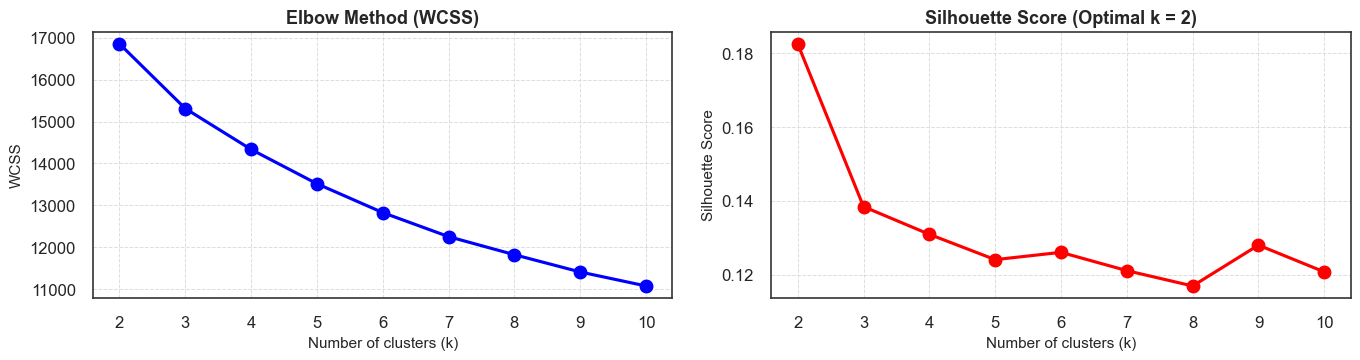

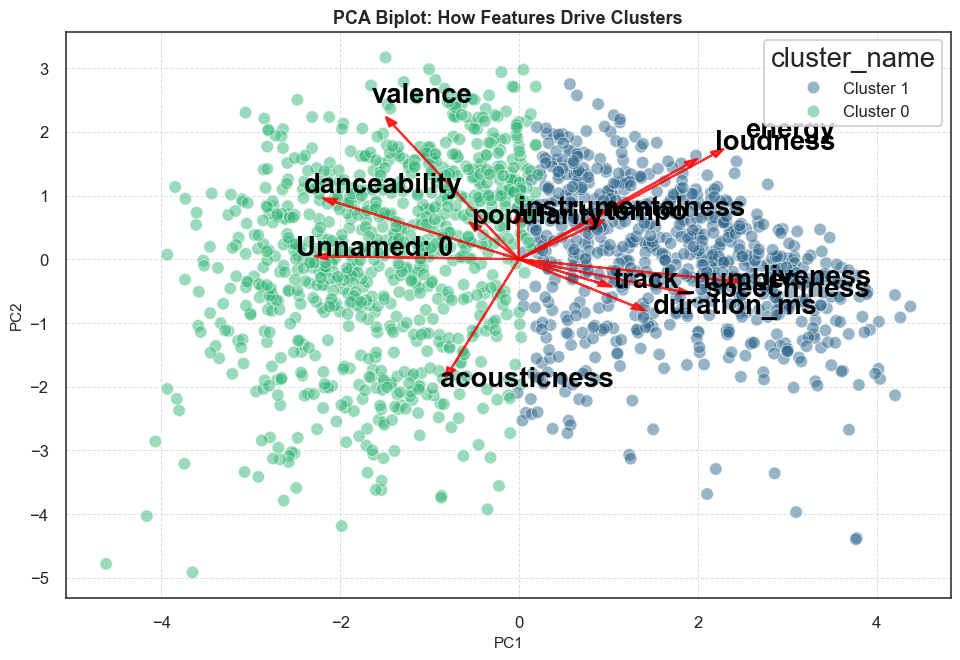

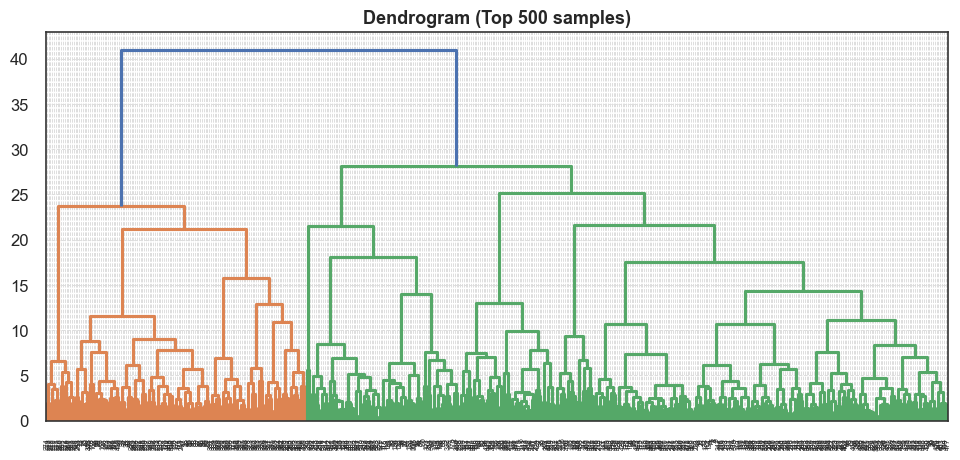

Executive Summary: Employee Segmentation via Clustering

We segmented 1610 employees into 2 distinct behavioral clusters based on satisfaction, evaluation, workload, and tenure.

Cluster Distribution (by share of population):
 - Cluster 0: 53.8% of employees
 - Cluster 1: 46.2% of employees

Cluster Personas and Key Insights:
* Cluster 0: This segment is characterized by the following average feature values: {'Unnamed: 0': 1069.43, 'track_number': 7.04, 'acousticness': 0.3, 'danceability': 0.55, 'energy': 0.7, 'instrumentalness': 0.18, 'liveness': 0.25, 'loudness': -8.28, 'speechiness': 0.05, 'tempo': 119.54, 'valence': 0.66, 'popularity': 23.03, 'duration_ms': 226669.59}. These values represent the central tendencies of this cluster relative to the dataset.
* Cluster 1: This segment is characterized by the following average feature values: {'Unnamed: 0': 496.12, 'track_number': 10.45, 'acousticness': 0.19, 'danceability': 0.38, 'energy': 0.91, 'instrumentalness': 0.15, 'liveness': 0.7

In [34]:
# 0. CONFIG
# ============================================================

RANDOM_STATE = 42
K_MIN, K_MAX = 2, 10

DBSCAN_EPS_GRID = [0.2, 0.3, 0.4, 0.5, 0.6]
DBSCAN_MIN_SAMPLES_GRID = [3, 5, 10]


# ============================================================
# 1. DATA PREP
# ============================================================

def prepare_data(df: pd.DataFrame, features: list) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    """
    Clean df, drop NaNs on selected features, return:
    - df_clean
    - X (raw feature matrix)
    - X_scaled (standardized features)
    """
    df_clean = df.dropna(subset=features).copy()
    X = df_clean[features].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return df_clean, X, X_scaled


# ============================================================
# 2. K-MEANS: OPTIMAL K (ELBOW + SILHOUETTE)
# ============================================================

def find_optimal_k(X_scaled: np.ndarray,
                   k_min: int = K_MIN,
                   k_max: int = K_MAX,
                   random_state: int = RANDOM_STATE) -> dict:
    """
    Compute WCSS and silhouette scores for k in [k_min, k_max].
    Returns dict with:
    - optimal_k
    - wcss
    - silhouette_scores
    """
    wcss = []
    silhouette_scores = []
    k_values = list(range(k_min, k_max + 1))

    for k in k_values:
        km = KMeans(
            n_clusters=k,
            n_init=10,
            init='k-means++',
            random_state=random_state
        )
        labels = km.fit_predict(X_scaled)
        wcss.append(km.inertia_)

        if k > 1:
            score = silhouette_score(X_scaled, labels)
        else:
            score = np.nan
        silhouette_scores.append(score)

    # choose k with max silhouette (ignoring NaNs)
    valid_scores = np.array(silhouette_scores, dtype=float)
    valid_scores[np.isnan(valid_scores)] = -1
    optimal_k = k_values[int(np.argmax(valid_scores))]

    return {
        "optimal_k": optimal_k,
        "k_values": k_values,
        "wcss": wcss,
        "silhouette_scores": silhouette_scores
    }


def plot_k_diagnostics(k_values, wcss, silhouette_scores, optimal_k: int) -> None:
    """
    Matplotlib elbow + silhouette plots.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(k_values, wcss, marker='o', color='blue')
    ax1.set_title('Elbow Method (WCSS)')
    ax1.set_xlabel('Number of clusters (k)')
    ax1.set_ylabel('WCSS')

    ax2.plot(k_values, silhouette_scores, marker='o', color='red')
    ax2.set_title(f'Silhouette Score (Optimal k = {optimal_k})')
    ax2.set_xlabel('Number of clusters (k)')
    ax2.set_ylabel('Silhouette Score')

    plt.tight_layout()
    plt.show()


# ============================================================
# 3. UNIFIED PIPELINE: SCALER + KMEANS
# ============================================================

def build_kmeans_pipeline(n_clusters: int,
                          random_state: int = RANDOM_STATE) -> Pipeline:
    """
    Unified sklearn pipeline: StandardScaler + KMeans.
    """
    pipe = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("kmeans", KMeans(
            n_clusters=n_clusters,
            n_init=10,
            init='k-means++',
            random_state=random_state
        ))
    ])
    return pipe


def fit_kmeans_and_assign(df_clean: pd.DataFrame,
                          features: list,
                          n_clusters: int) -> tuple[pd.DataFrame, Pipeline, np.ndarray]:
    """
    Fit KMeans pipeline and assign cluster labels to df_clean.
    Returns:
    - df_with_clusters
    - fitted pipeline
    - X_scaled (from pipeline)
    """
    pipe = build_kmeans_pipeline(n_clusters=n_clusters)
    X = df_clean[features].values
    labels = pipe.fit_predict(X)

    df_clean = df_clean.copy()
    df_clean["cluster"] = labels

    # Extract scaled features from pipeline
    X_scaled = pipe.named_steps["scaler"].transform(X)

    return df_clean, pipe, X_scaled


# ============================================================
# 4. CLUSTER NAMING & PERSONAS
# ============================================================

def name_clusters(df_clusters: pd.DataFrame,
                  features: list,
                  cluster_col: str = "cluster") -> dict:
    """
    Generic cluster naming: Cluster 0, Cluster 1, ...
    """
    cluster_names = {}
    for c in sorted(df_clusters[cluster_col].unique()):
        cluster_names[c] = f"Cluster {c}"
    return cluster_names

def attach_cluster_names(df_clusters: pd.DataFrame,
                         cluster_names: dict,
                         cluster_col: str = "cluster") -> pd.DataFrame:
    """
    Map numeric cluster labels to human-readable names.
    """
    df_clusters = df_clusters.copy()
    df_clusters["cluster_name"] = df_clusters[cluster_col].map(cluster_names)
    return df_clusters


def build_cluster_personas(df_clusters: pd.DataFrame,
                           features: list,
                           cluster_col: str = "cluster",
                           cluster_name_col: str = "cluster_name") -> dict:
    """
    Fully generic persona engine.
    Produces a narrative based on average feature values.
    """
    personas = {}

    for c in sorted(df_clusters[cluster_col].unique()):
        c_df = df_clusters[df_clusters[cluster_col] == c]
        name = c_df[cluster_name_col].iloc[0]

        # Generic summary of feature means
        summary = c_df[features].mean().round(2).to_dict()

        persona = (
            f"{name}: This segment is characterized by the following average feature values: "
            f"{summary}. "
            "These values represent the central tendencies of this cluster relative to the dataset."
        )

        personas[name] = persona

    return personas

def build_executive_narrative(df_clusters: pd.DataFrame,
                              personas: dict,
                              cluster_name_col: str = "cluster_name") -> str:
    """
    High-level executive summary of the clustering outcome.
    """
    total = len(df_clusters)
    cluster_counts = df_clusters[cluster_name_col].value_counts(normalize=True).sort_values(ascending=False)

    lines = []
    lines.append("Executive Summary: Employee Segmentation via Clustering\n")
    lines.append(
        f"We segmented {total} employees into {df_clusters[cluster_name_col].nunique()} distinct behavioral clusters "
        "based on satisfaction, evaluation, workload, and tenure."
    )
    lines.append("")

    lines.append("Cluster Distribution (by share of population):")
    for name, frac in cluster_counts.items():
        lines.append(f" - {name}: {frac*100:.1f}% of employees")

    lines.append("")
    lines.append("Cluster Personas and Key Insights:")
    for name, text in personas.items():
        lines.append(f"* {text}")

    narrative = "\n".join(lines)
    return narrative


# ============================================================
# 5. PCA + BIPLOT
# ============================================================

def compute_pca(X_scaled: np.ndarray, n_components: int = 2) -> tuple[np.ndarray, PCA]:
    """
    Fit PCA and return components + fitted object.
    """
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    components = pca.fit_transform(X_scaled)
    return components, pca


def add_pca_to_df(df_clusters: pd.DataFrame,
                  pca_components: np.ndarray) -> pd.DataFrame:
    """
    Add PC1, PC2 to df.
    """
    df_clusters = df_clusters.copy()
    df_clusters["PC1"] = pca_components[:, 0]
    df_clusters["PC2"] = pca_components[:, 1]
    return df_clusters


def plot_pca_biplot(df_clusters: pd.DataFrame,
                    pca: PCA,
                    features: list,
                    cluster_name_col: str = "cluster_name",
                    scale_factor: float = 3.0) -> None:
    """
    PCA biplot with feature loadings.
    """
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        x="PC1",
        y="PC2",
        hue=cluster_name_col,
        palette="viridis",
        data=df_clusters,
        alpha=0.5
    )

    for i, feature in enumerate(features):
        plt.arrow(
            0, 0,
            loadings[i, 0] * scale_factor,
            loadings[i, 1] * scale_factor,
            color="red",
            alpha=0.8,
            head_width=0.1
        )
        plt.text(
            loadings[i, 0] * (scale_factor + 0.5),
            loadings[i, 1] * (scale_factor + 0.5),
            feature,
            color="black",
            weight="bold"
        )

    plt.title("PCA Biplot: How Features Drive Clusters")
    plt.tight_layout()
    plt.show()


# ============================================================
# 6. HIERARCHICAL CLUSTERING (DENDROGRAM)
# ============================================================

def plot_dendrogram(X_scaled: np.ndarray,
                    max_samples: int = 500) -> None:
    """
    Plot dendrogram on a subset for speed.
    """
    subset = X_scaled[:max_samples]
    plt.figure(figsize=(10, 5))
    shc.dendrogram(shc.linkage(subset, method="ward"))
    plt.title(f"Dendrogram (Top {len(subset)} samples)")
    plt.tight_layout()
    plt.show()


# ============================================================
# 7. AUTO-TUNED DBSCAN
# ============================================================

def auto_tune_dbscan(X_scaled: np.ndarray,
                     eps_grid=DBSCAN_EPS_GRID,
                     min_samples_grid=DBSCAN_MIN_SAMPLES_GRID) -> dict:
    """
    Grid search over eps and min_samples using silhouette score.
    Returns dict with:
    - best_eps
    - best_min_samples
    - best_score
    - best_labels
    """
    best_score = -1
    best_params = {"eps": None, "min_samples": None}
    best_labels = None

    for eps in eps_grid:
        for ms in min_samples_grid:
            db = DBSCAN(eps=eps, min_samples=ms)
            labels = db.fit_predict(X_scaled)

            # ignore cases where all points are noise or single cluster
            unique_labels = set(labels)
            if len(unique_labels) <= 1:
                continue
            if len(unique_labels - {-1}) <= 1:
                continue

            try:
                score = silhouette_score(X_scaled, labels)
            except Exception:
                continue

            if score > best_score:
                best_score = score
                best_params["eps"] = eps
                best_params["min_samples"] = ms
                best_labels = labels

    return {
        "best_eps": best_params["eps"],
        "best_min_samples": best_params["min_samples"],
        "best_score": best_score,
        "best_labels": best_labels
    }


def attach_dbscan_labels(df_clusters: pd.DataFrame,
                         dbscan_result: dict,
                         col_name: str = "db_cluster") -> pd.DataFrame:
    """
    Attach DBSCAN cluster labels to df.
    """
    df_clusters = df_clusters.copy()
    if dbscan_result["best_labels"] is not None:
        df_clusters[col_name] = dbscan_result["best_labels"]
    else:
        df_clusters[col_name] = -1  # all noise / no good solution
    return df_clusters


# ============================================================
# 8. PLOTLY DASHBOARD WITH TABS
# ============================================================

def build_plotly_dashboard_with_tabs(df_clusters: pd.DataFrame,
                                     features: list,
                                     cluster_name_col: str = "cluster_name"):

    # --- Tab 1: PCA Scatter ---
    fig_pca = px.scatter(
        df_clusters,
        x="PC1",
        y="PC2",
        color=cluster_name_col,
        title="Cluster Map (PCA Projection)",
        hover_data=features,
        template="plotly_white"
    )

    # --- Tab 2: Cluster Profile Heatmap ---
    profile_means = df_clusters.groupby(cluster_name_col)[features].mean().reset_index()
    profile_melt = profile_means.melt(
        id_vars=cluster_name_col,
        var_name="feature",
        value_name="value"
    )

    fig_profile = px.imshow(
        profile_means.set_index(cluster_name_col)[features],
        aspect="auto",
        color_continuous_scale="Blues",
        labels=dict(color="Mean Value"),
        title="Cluster Profile (Feature Means)"
    )

    # --- Tab 3: DBSCAN Cluster Map (if available) ---
    has_dbscan = "db_cluster" in df_clusters.columns
    if has_dbscan:
        fig_db = px.scatter(
            df_clusters,
            x="PC1",
            y="PC2",
            color="db_cluster",
            title="DBSCAN Cluster Map (PCA Projection)",
            hover_data=features,
            template="plotly_white"
        )

    # --- Combine into one figure with buttons as tabs ---
    dashboard = make_subplots(rows=1, cols=1)

    # Add traces for each "tab"
    # Tab 1 traces
    for trace in fig_pca.data:
        dashboard.add_trace(trace, row=1, col=1)
    pca_trace_count = len(fig_pca.data)

    # Tab 2 traces
    for trace in fig_profile.data:
        dashboard.add_trace(trace, row=1, col=1)
    profile_trace_count = len(fig_profile.data)

    # Tab 3 traces
    db_trace_count = 0
    if has_dbscan:
        for trace in fig_db.data:
            dashboard.add_trace(trace, row=1, col=1)
        db_trace_count = len(fig_db.data)

    # Build visibility masks
    total_traces = pca_trace_count + profile_trace_count + db_trace_count

    def tab_visibility(tab_index: int):
        """
        tab_index: 0 = PCA, 1 = Profile, 2 = DBSCAN
        """
        vis = [False] * total_traces
        if tab_index == 0:
            for i in range(pca_trace_count):
                vis[i] = True
        elif tab_index == 1:
            for i in range(pca_trace_count, pca_trace_count + profile_trace_count):
                vis[i] = True
        elif tab_index == 2 and has_dbscan:
            start = pca_trace_count + profile_trace_count
            for i in range(start, start + db_trace_count):
                vis[i] = True
        return vis

    updatemenus = [
        dict(
            type="buttons",
            direction="right",
            x=0.5,
            y=1.15,
            showactive=True,
            buttons=[
                dict(
                    label="PCA Map",
                    method="update",
                    args=[{"visible": tab_visibility(0)},
                          {"title": "Cluster Map (PCA Projection)"}]
                ),
                dict(
                    label="Cluster Profiles",
                    method="update",
                    args=[{"visible": tab_visibility(1)},
                          {"title": "Cluster Profile (Feature Means)"}]
                ),
            ] + (
                [
                    dict(
                        label="DBSCAN Map",
                        method="update",
                        args=[{"visible": tab_visibility(2)},
                              {"title": "DBSCAN Cluster Map (PCA Projection)"}]
                    )
                ] if has_dbscan else []
            )
        )
    ]

    dashboard.update_layout(
        height=800,
        template="plotly_white",
        updatemenus=updatemenus,
        showlegend=True,
        title="Cluster Dashboard"
    )

    # Default: show PCA tab
    dashboard.update_traces(visible=True, selector=dict())
    vis0 = tab_visibility(0)
    for i, v in enumerate(vis0):
        dashboard.data[i].visible = v

    dashboard.show()
    return dashboard


# ============================================================
# 9. ORCHESTRATION FUNCTION
# ============================================================

def run_full_clustering_pipeline(df: pd.DataFrame,
                                 features: list = None) -> dict:
    
    # Auto-detect numeric features if none provided
    if features is None:
        features = df.select_dtypes(include='number').columns.tolist()
    """
    Orchestrates the full clustering workflow:
    - data prep
    - optimal k search
    - kmeans pipeline + labels
    - cluster naming + personas
    - PCA + biplot
    - hierarchical dendrogram
    - auto-tuned DBSCAN
    - plotly dashboard with tabs
    - executive narrative
    Returns a dict of key artifacts.
    """
    # 1. Data prep
    df_clean, X, X_scaled = prepare_data(df, features)

    # 2. Optimal k
    k_results = find_optimal_k(X_scaled)
    optimal_k = k_results["optimal_k"]
    plot_k_diagnostics(
        k_results["k_values"],
        k_results["wcss"],
        k_results["silhouette_scores"],
        optimal_k
    )

    # 3. KMeans pipeline + labels
    df_clusters, kmeans_pipe, X_scaled_pipe = fit_kmeans_and_assign(
        df_clean, features, optimal_k
    )

    # 4. Cluster naming + personas
    cluster_names = name_clusters(df_clusters, features)
    df_clusters = attach_cluster_names(df_clusters, cluster_names)
    personas = build_cluster_personas(df_clusters, features)
    narrative = build_executive_narrative(df_clusters, personas)

    # 5. PCA + biplot
    pca_components, pca_model = compute_pca(X_scaled_pipe, n_components=2)
    df_clusters = add_pca_to_df(df_clusters, pca_components)
    plot_pca_biplot(df_clusters, pca_model, features)

    # 6. Hierarchical dendrogram
    plot_dendrogram(X_scaled_pipe, max_samples=500)

    # 7. Auto-tuned DBSCAN
    dbscan_result = auto_tune_dbscan(X_scaled_pipe)
    df_clusters = attach_dbscan_labels(df_clusters, dbscan_result)

    # 8. Plotly dashboard with tabs
    dashboard_fig = build_plotly_dashboard_with_tabs(df_clusters, features)

    return {
        "df_clusters": df_clusters,
        "kmeans_pipeline": kmeans_pipe,
        "optimal_k": optimal_k,
        "k_search_results": k_results,
        "pca_model": pca_model,
        "dbscan_result": dbscan_result,
        "cluster_names": cluster_names,
        "personas": personas,
        "executive_narrative": narrative,
        "dashboard_figure": dashboard_fig
    }


# ============================================================
# 10. EXAMPLE CALL
# ============================================================
# Example usage with custom features
my_features = ['col1', 'col2', 'col3', 'col4']
results = run_full_clustering_pipeline(df)

print(results["executive_narrative"])

---
# Dimensionality Reduction 

### FULL PIPELINE: Dimensionality Reduction + Clustering + Association Rules + Anomaly Detection

In [39]:
# LOGGING
# ============================================================
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


# ============================================================
# ASSOCIATION ENGINE (PARALLEL + EXPLAINABLE)
# ============================================================
class AssociationEngine:

    def __init__(self, min_support_range=(0.01, 0.05), min_conf_range=(0.2, 0.6), n_jobs=-1):
        self.min_support_range = min_support_range
        self.min_conf_range = min_conf_range
        self.n_jobs = n_jobs

    def _to_transactions(self, df_cat):
        return [[f"{col}={row[col]}" for col in df_cat.columns] for _, row in df_cat.iterrows()]

    # -------------------------------------------------
    # Optimized ECLAT: 1- & 2-itemsets, optional 3-itemsets
    # -------------------------------------------------
    def _eclat(self, transactions, min_support):
        item_tid = defaultdict(set)

        # Build TID sets
        for tid, trans in enumerate(transactions):
            for item in trans:
                item_tid[item].add(tid)

        total = len(transactions)
        if total == 0:
            return {}

        # Singleton supports
        singleton_supports = {
            item: len(tids) / total
            for item, tids in item_tid.items()
        }

        # Prune low-support singletons
        frequent_items = {
            item: supp for item, supp in singleton_supports.items()
            if supp >= min_support
        }
        items = list(frequent_items.keys())

        frequent = {}

        # 1-itemsets
        for item, supp in frequent_items.items():
            frequent[frozenset([item])] = supp

        # 2-itemsets
        for i in range(len(items)):
            for j in range(i + 1, len(items)):
                a, b = items[i], items[j]
                tids_ab = item_tid[a] & item_tid[b]
                supp_ab = len(tids_ab) / total
                if supp_ab >= min_support:
                    frequent[frozenset([a, b])] = supp_ab

        # Optional 3-itemsets (only from very frequent singles)
        high_sup_threshold = min(1.0, min_support * 2.0)
        high_items = [
            item for item, supp in frequent_items.items()
            if supp >= high_sup_threshold
        ]

        for i in range(len(high_items)):
            for j in range(i + 1, len(high_items)):
                for k in range(j + 1, len(high_items)):
                    a, b, c = high_items[i], high_items[j], high_items[k]
                    tids_abc = item_tid[a] & item_tid[b] & item_tid[c]
                    supp_abc = len(tids_abc) / total
                    if supp_abc >= high_sup_threshold:
                        frequent[frozenset([a, b, c])] = supp_abc

        return frequent

    def _generate_rules(self, itemsets):
        rules = []

        for itemset, support in itemsets.items():
            if len(itemset) < 2:
                continue  # no rules from singletons

            for item in itemset:
                antecedent = frozenset([item])
                consequent = itemset - antecedent

                support_a = itemsets.get(antecedent, support)
                support_b = itemsets.get(consequent, support)

                if support_a > 0 and support_b > 0:
                    confidence = support / support_a
                    lift = confidence / support_b

                    rules.append({
                        "antecedents": antecedent,
                        "consequents": consequent,
                        "support": support,
                        "confidence": confidence,
                        "lift": lift
                    })

        return pd.DataFrame(rules)

    def _evaluate(self, rules):
        if rules.empty:
            return 0, {}

        metrics = {
            "lift_mean": rules["lift"].mean(),
            "confidence_mean": rules["confidence"].mean(),
            "support_mean": rules["support"].mean(),
            "rule_count": len(rules)
        }

        score = (
            metrics["lift_mean"] * 0.4 +
            metrics["confidence_mean"] * 0.3 +
            metrics["support_mean"] * 0.2 +
            metrics["rule_count"] * 0.1 / 1000
        )

        return score, metrics

    def _run_apriori(self, df_encoded, sup, conf):
        frequent = apriori(df_encoded, min_support=sup, use_colnames=True)

        # SAFETY CHECK: no frequent itemsets
        if frequent.empty:
            empty_rules = pd.DataFrame(columns=["antecedents", "consequents", "support", "confidence", "lift"])
            score, metrics = self._evaluate(empty_rules)
            return ("Apriori", sup, conf, empty_rules, score, metrics)

        rules = association_rules(frequent, metric="confidence", min_threshold=conf)
        score, metrics = self._evaluate(rules)
        return ("Apriori", sup, conf, rules, score, metrics)

    def _run_eclat(self, transactions, sup):
        itemsets = self._eclat(transactions, sup)
        rules = self._generate_rules(itemsets)
        score, metrics = self._evaluate(rules)
        return ("Eclat", sup, None, rules, score, metrics)

    # -------------------------------------------------
    # Cluster-Based Market Basket Analysis (Top Items)
    # -------------------------------------------------
    def cluster_market_baskets(self, df_encoded, cluster_labels):
        df_clustered = df_encoded.copy()
        df_clustered["Cluster"] = cluster_labels

        cluster_top_items = {}

        for c in sorted(df_clustered["Cluster"].unique()):
            sub = df_clustered[df_clustered["Cluster"] == c].drop(columns=["Cluster"])
            item_support = sub.mean().sort_values(ascending=False)
            cluster_top_items[c] = item_support.head(10)

        return cluster_top_items

    def fit(self, df_categorical, cluster_labels=None):

        if df_categorical.shape[1] == 0:
            return pd.DataFrame(), {}, {}, {}


        df_encoded = pd.get_dummies(df_categorical)
        transactions = self._to_transactions(df_categorical)

        tasks = []
        for sup in np.linspace(*self.min_support_range, 3):
            for conf in np.linspace(*self.min_conf_range, 3):
                tasks.append(("apriori", sup, conf))
            tasks.append(("eclat", sup, None))

        results = Parallel(n_jobs=self.n_jobs)(
            delayed(self._run_apriori)(df_encoded, sup, conf) if t == "apriori"
            else delayed(self._run_eclat)(transactions, sup)
            for t, sup, conf in tasks
        )

        best = max(results, key=lambda x: x[4])
        method, sup, conf, rules, score, metrics = best

        explanation = {
            "method": method,
            "support": sup,
            "confidence": conf,
            "metrics": metrics
        }

        cluster_rules = {}
        if cluster_labels is not None:
            df_temp = df_categorical.copy()
            df_temp["Cluster"] = cluster_labels

            for c in df_temp["Cluster"].unique():
                subset = df_temp[df_temp["Cluster"] == c].drop(columns="Cluster")
                if len(subset) > 10:
                    try:
                        sub_rules, _, _, _ = self.fit(subset)
                        cluster_rules[c] = sub_rules.head(5)
                    except:
                        continue

        # Market basket cluster profiles (top items)
        cluster_top_items = {}
        if cluster_labels is not None:
            cluster_top_items = self.cluster_market_baskets(df_encoded, cluster_labels)

        return rules, explanation, cluster_rules, cluster_top_items


# ============================================================
# MAIN PIPELINE
# ============================================================
class SmartUnsupervisedPipeline:

    def __init__(self, max_k=10, contamination=0.05):
        self.scaler = StandardScaler()
        self.max_k = max_k
        self.contamination = contamination
        self.association_engine = AssociationEngine()

    def preprocess(self, df):
        self.numeric = df.select_dtypes(include=np.number)
        self.categorical = df.select_dtypes(exclude=np.number)

        X = SimpleImputer(strategy="mean").fit_transform(self.numeric)
        return self.scaler.fit_transform(X)

    # ---------------------------------------------
    # DIMENSIONALITY REDUCTION SELECTION
    # ---------------------------------------------
    def select_dimensionality(self, X, y=None):
        methods = {"none": X}

        # PCA
        for n in range(2, min(X.shape[1], 10)):
            methods[f"PCA_{n}"] = PCA(n_components=n).fit_transform(X)

        # t-SNE (limit for performance)
        if X.shape[0] < 2000:
            try:
                methods["TSNE"] = TSNE(n_components=2, random_state=42).fit_transform(X)
            except:
                pass

        # LDA (if labels exist)
        if y is not None:
            try:
                methods["LDA"] = LinearDiscriminantAnalysis(n_components=2).fit_transform(X, y)
            except:
                pass

        best_score = -1

        for name, data in methods.items():
            try:
                labels = KMeans(n_clusters=3, n_init=10).fit_predict(data)
                score = silhouette_score(data, labels)

                if score > best_score:
                    best_score = score
                    self.best_dr = name
                    best_data = data
            except:
                continue

        logger.info(f"Best DR: {self.best_dr}")
        return best_data

    # ---------------------------------------------
    # AUTO K SELECTION
    # ---------------------------------------------
    def find_best_k(self, X):
        best_k, best_score = 2, -1

        for k in range(2, self.max_k + 1):
            labels = KMeans(n_clusters=k, n_init=10).fit_predict(X)
            score = silhouette_score(X, labels)

            if score > best_score:
                best_k, best_score = k, score

        self.best_k = best_k
        logger.info(f"Best K: {best_k}")
        return best_k

    def cluster(self, X):
        self.labels = KMeans(n_clusters=self.best_k, n_init=10).fit_predict(X)
        return self.labels

    # ---------------------------------------------
    # FULL ANOMALY PIPELINE (Code 1 logic on reduced X)
    # ---------------------------------------------
    def _compute_fraud_risk(self, scores):
        inv = -scores
        min_v, max_v = inv.min(), inv.max()
        if max_v == min_v:
            return np.zeros_like(inv)
        return (inv - min_v) / (max_v - min_v)

    def _build_anomaly_dashboard(self, df_with_scores, amount_col=None):
        # amount_col may not exist in generic unsupervised data; guard it
        if amount_col is None or amount_col not in df_with_scores.columns:
            amount_col = df_with_scores.columns[0]

        fig_scatter = px.scatter(
            df_with_scores,
            x=amount_col,
            y="Anomaly Score",
            color=df_with_scores["Anomaly"].map({1: "Normal", -1: "Anomaly"}),
            color_discrete_map={"Normal": "steelblue", "Anomaly": "red"},
            size="Fraud_Risk",
            title="Amount vs Anomaly Score (size = Fraud Risk)",
            labels={amount_col: amount_col, "Anomaly Score": "Anomaly Score"},
            template="plotly_white"
        )

        fig_hist = px.histogram(
            df_with_scores,
            x="Fraud_Risk",
            nbins=30,
            color=df_with_scores["Anomaly"].map({1: "Normal", -1: "Anomaly"}),
            color_discrete_map={"Normal": "steelblue", "Anomaly": "red"},
            title="Fraud Risk Distribution",
            template="plotly_white"
        )

        if "Class" in df_with_scores.columns:
            risk_by_class = (
                df_with_scores
                .groupby("Class")["Fraud_Risk"]
                .mean()
                .reset_index()
            )
            fig_bar = px.bar(
                risk_by_class,
                x="Class",
                y="Fraud_Risk",
                title="Average Fraud Risk by True Class",
                template="plotly_white"
            )
        else:
            fig_bar = None

        return {
            "scatter_amount_vs_score": fig_scatter,
            "hist_fraud_risk": fig_hist,
            "bar_risk_by_class": fig_bar
        }

    def detect_anomalies(self, X, df_original=None):
        iso = IsolationForest(
            contamination=self.contamination,
            random_state=42
        )
        iso.fit(X)

        preds = iso.predict(X)               # +1 normal, -1 anomaly
        scores = iso.decision_function(X)    # more negative = more anomalous
        fraud_risk = self._compute_fraud_risk(scores)

        df_scores = pd.DataFrame({
            "Anomaly": preds,
            "Anomaly Score": scores,
            "Fraud_Risk": fraud_risk
        })

        if df_original is not None:
            df_scores = pd.concat([df_original.reset_index(drop=True), df_scores], axis=1)

        dashboard_figs = self._build_anomaly_dashboard(df_scores, amount_col=None)

        counts = pd.Series(preds).value_counts()

        return {
            "model": iso,
            "predictions": preds,
            "scores": scores,
            "fraud_risk": fraud_risk,
            "counts": counts,
            "df_with_scores": df_scores,
            "dashboard_figs": dashboard_figs
        }

    # ---------------------------------------------
    # PLOTLY DASHBOARD (CLUSTERS)
    # ---------------------------------------------
    def build_dashboard(self, X):
        df_plot = pd.DataFrame(X[:, :2], columns=["Dim1", "Dim2"])
        df_plot["Cluster"] = self.labels

        fig = px.scatter(df_plot, x="Dim1", y="Dim2", color="Cluster",
                         title=f"Clusters ({self.best_dr})")
        fig.show()
        return fig

    # ---------------------------------------------
    # PARALLEL COORDINATES FOR ITEMSET PATTERNS
    # ---------------------------------------------
    def build_parallel_coordinates_for_itemsets(self, frequent_itemsets, top_n=20):
        if frequent_itemsets is None or frequent_itemsets.empty:
            return None

        top = frequent_itemsets.head(top_n).copy()

        if "itemsets" not in top.columns:
            return None

        all_items = sorted({item for items in top["itemsets"] for item in items})

        for item in all_items:
            top[str(item)] = top["itemsets"].apply(lambda s: 1 if item in s else 0)

        dims = [str(item) for item in all_items] + ["support"]

        fig = px.parallel_coordinates(
            top,
            dimensions=dims,
            color="support",
            color_continuous_scale=px.colors.sequential.Viridis,
            title="Parallel Coordinates of Top Frequent Itemsets"
        )
        return fig

    def fit(self, df_processed, y=None):

        # 1) Preprocess
        X = self.preprocess(df_processed)

        # 2) Dimensionality reduction
        X = self.select_dimensionality(X, y)

        # 3) Auto K
        self.find_best_k(X)

        # 4) Clustering
        clusters = self.cluster(X)

        # 5) Full anomaly pipeline on reduced X
        anomaly_results = self.detect_anomalies(X, df_original=df_processed)
        anomalies = anomaly_results["predictions"]

        # 6) Association rules (with cluster awareness)
        rules, explanation, cluster_rules, cluster_top_items = \
            self.association_engine.fit(self.categorical, clusters)

        # 7) Parallel coordinates for itemsets
        parallel_fig = None
        if "itemsets" in rules.columns:
            parallel_fig = self.build_parallel_coordinates_for_itemsets(rules)

        # 8) Cluster dashboard
        self.build_dashboard(X)

        # 9) Final result frame
        result = df_processed.copy()
        result["Cluster"] = clusters
        result["Anomaly"] = anomalies
        result["Fraud_Risk"] = anomaly_results["fraud_risk"]

        return {
            "data": result,
            "best_k": self.best_k,
            "best_dr": self.best_dr,
            "rules": rules,
            "explanation": explanation,
            "cluster_rules": cluster_rules,
            "cluster_top_items": cluster_top_items,
            "parallel_coordinates": parallel_fig,
            "anomaly_model": anomaly_results["model"],
            "anomaly_counts": anomaly_results["counts"],
            "anomaly_dashboard": anomaly_results["dashboard_figs"],
            "df_with_anomaly_scores": anomaly_results["df_with_scores"]
        }
smart_pipeline = SmartUnsupervisedPipeline(max_k=10, contamination=0.05)
results = smart_pipeline.fit(df_processed)

2026-05-06 22:40:05,281 — INFO — Best DR: PCA_2
2026-05-06 22:40:06,198 — INFO — Best K: 2


### Association rule learning from classroom instructions

In [ ]:
# 1. TRANSACTION CONVERSION
# ============================================================

def df_to_transactions(df):
    """
    Convert a dataframe of categorical columns into a list of transactions.
    Each row becomes a list of 'column=value' strings.
    """
    return [
        [f"{col}={row[col]}" for col in df.columns]
        for _, row in df.iterrows()
    ]


# ============================================================
# 2. ONE-HOT ENCODING
# ============================================================

def encode_transactions(transactions):
    """
    Convert list-of-lists transactions into a one-hot encoded DataFrame.
    """
    all_items = sorted({item for trans in transactions for item in trans})
    df = pd.DataFrame(0, index=range(len(transactions)), columns=all_items)

    for i, trans in enumerate(transactions):
        for item in trans:
            df.at[i, item] = 1

    return df


# ============================================================
# 3. APRIORI + ASSOCIATION RULES
# ============================================================

def run_apriori(df_encoded, min_support=0.01, min_confidence=0.2):
    frequent_itemsets = apriori(
        df_encoded,
        min_support=min_support,
        use_colnames=True
    )

    rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=min_confidence
    )

    return frequent_itemsets, rules


# ============================================================
# 4. TRAIN/TEST SPLIT FOR ECLAT
# ============================================================

def split_transactions(transactions, test_size=0.2):
    n = len(transactions)
    split = int(n * (1 - test_size))
    return transactions[:split], transactions[split:]


# ============================================================
# 5. RUN ECLAT
# ============================================================

def run_eclat(train_transactions, min_support=0.01, min_comb=1, max_comb=2):
    train_df = pd.DataFrame(train_transactions)

    eclat = ECLAT(data=train_df, verbose=False)
    support_dict, frequent_itemsets = eclat.fit(
        min_support=min_support,
        min_combination=min_comb,
        max_combination=max_comb
    )

    total = len(train_transactions)
    frequent_df = pd.DataFrame({
        "Itemset": list(frequent_itemsets.keys()),
        "Support": [len(support_dict[item]) / total for item in frequent_itemsets.keys()]
    }).sort_values("Support", ascending=False)

    return frequent_df


# ============================================================
# 6. CLUSTER-BASED MARKET BASKET ANALYSIS
# ============================================================

def cluster_market_baskets(df_encoded, n_clusters=4):
    km = KMeans(n_clusters=n_clusters, random_state=42)
    labels = km.fit_predict(df_encoded.astype(float))

    df_clustered = df_encoded.copy()
    df_clustered["cluster"] = labels

    cluster_top_items = {}
    for c in sorted(df_clustered["cluster"].unique()):
        sub = df_clustered[df_clustered["cluster"] == c].drop(columns=["cluster"])
        item_support = sub.mean().sort_values(ascending=False)
        cluster_top_items[c] = item_support.head(10)

    return df_clustered, cluster_top_items


# ============================================================
# 7. PARALLEL COORDINATES FOR ITEMSET PATTERNS
# ============================================================

def build_parallel_coordinates_for_itemsets(frequent_itemsets, top_n=20):
    if frequent_itemsets.empty:
        return None

    top = frequent_itemsets.head(top_n).copy()

    # Extract all unique items
    all_items = sorted({item for items in top["itemsets"] for item in items})

    # Create binary indicator columns
    for item in all_items:
        top[str(item)] = top["itemsets"].apply(lambda s: 1 if item in s else 0)

    dims = [str(item) for item in all_items] + ["support"]

    fig = px.parallel_coordinates(
        top,
        dimensions=dims,
        color="support",
        color_continuous_scale=px.colors.sequential.Viridis,
        title="Parallel Coordinates of Top Frequent Itemsets"
    )
    return fig


# ============================================================
# 8. MARKET BASKET DASHBOARD
# ============================================================

def build_market_basket_dashboard(results):
    frequent_itemsets = results["frequent_itemsets"]
    rules = results["association_rules"]
    eclat_results = results["eclat_results"]

    # Top Apriori itemsets
    top_itemsets = frequent_itemsets.head(20).copy()
    top_itemsets["itemset_str"] = top_itemsets["itemsets"].apply(lambda s: ", ".join(list(s)))

    fig_itemsets = px.bar(
        top_itemsets,
        x="itemset_str",
        y="support",
        title="Top Frequent Itemsets (Apriori)",
        template="plotly_white"
    )

    # Rules scatter
    if not rules.empty:
        fig_rules = px.scatter(
            rules,
            x="support",
            y="confidence",
            color="lift",
            hover_data=["antecedents", "consequents"],
            title="Association Rules (Support vs Confidence)",
            template="plotly_white"
        )
    else:
        fig_rules = px.scatter(title="No Rules Found", template="plotly_white")

    # ECLAT itemsets
    top_eclat = eclat_results.head(20).copy()
    top_eclat["itemset_str"] = top_eclat["Itemset"].apply(lambda s: ", ".join(list(s)))

    fig_eclat = px.bar(
        top_eclat,
        x="itemset_str",
        y="Support",
        title="Top Frequent Itemsets (ECLAT)",
        template="plotly_white"
    )

    # Parallel coordinates
    fig_parallel = build_parallel_coordinates_for_itemsets(frequent_itemsets)

    return {
        "apriori_itemsets": fig_itemsets,
        "rules_scatter": fig_rules,
        "eclat_itemsets": fig_eclat,
        "parallel_coordinates": fig_parallel
    }


# ============================================================
# 9. MASTER PIPELINE
# ============================================================

def market_basket_pipeline(data,
                           apriori_support=0.01,
                           apriori_confidence=0.2,
                           eclat_support=0.01,
                           n_clusters=4):

    # Step 1: Convert to transactions
    transactions = df_to_transactions(data)

    # Step 2: One-hot encode
    df_encoded = encode_transactions(transactions)

    # Step 3: Apriori + Rules
    frequent_itemsets, rules = run_apriori(
        df_encoded,
        min_support=apriori_support,
        min_confidence=apriori_confidence
    )

    # Step 4: Train/Test split for ECLAT
    train_trans, test_trans = split_transactions(transactions)

    # Step 5: ECLAT
    eclat_results = run_eclat(
        train_trans,
        min_support=eclat_support,
        min_comb=1,
        max_comb=2
    )

    # Step 6: Cluster-based market basket analysis
    df_clustered, cluster_top_items = cluster_market_baskets(df_encoded, n_clusters=n_clusters)

    # Step 7: Dashboard figs
    dashboard_figs = build_market_basket_dashboard({
        "frequent_itemsets": frequent_itemsets,
        "association_rules": rules,
        "eclat_results": eclat_results
    })

    return {
        "transactions": transactions,
        "df_encoded": df_encoded,
        "frequent_itemsets": frequent_itemsets,
        "association_rules": rules,
        "train_transactions": train_trans,
        "test_transactions": test_trans,
        "eclat_results": eclat_results,
        "clustered_df": df_clustered,
        "cluster_top_items": cluster_top_items,
        "dashboard_figs": dashboard_figs
    }


### Anomaly Detection Techniques from classroom instruction

In [ ]:
# 1. PREPARE DATA
# ============================================================

def prepare_data(df, feature_cols, target_col='Class', test_size=0.2):
    X = df[feature_cols]
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    return X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()


# ============================================================
# 2. TRAIN ISOLATION FOREST
# ============================================================

def train_isolation_forest(X_train, contamination=0.01):
    iso = IsolationForest(
        contamination=contamination,
        random_state=42
    )
    iso.fit(X_train)
    return iso


# ============================================================
# 3. PREDICT ANOMALIES
# ============================================================

def predict_anomalies(model, X):
    preds = model.predict(X)               # +1 normal, -1 anomaly
    scores = model.decision_function(X)    # more negative = more anomalous
    return preds, scores


# ============================================================
# 4. FRAUD‑RISK SCORING
# ============================================================

def add_fraud_risk_score(df_with_scores, score_col='Anomaly Score', new_col='Fraud_Risk'):
    """
    Convert anomaly scores to a 0–1 fraud‑risk score.
    More negative anomaly score → higher risk.
    """
    scores = df_with_scores[score_col].values
    # Invert (so higher = more anomalous), then min‑max scale
    inv = -scores
    min_v, max_v = inv.min(), inv.max()
    if max_v == min_v:
        risk = np.zeros_like(inv)
    else:
        risk = (inv - min_v) / (max_v - min_v)
    df_with_scores[new_col] = risk
    return df_with_scores


# ============================================================
# 5. EVALUATION SUMMARY
# ============================================================

def evaluate_results(X_test_with_scores, preds):
    summary = X_test_with_scores.copy()
    summary['Anomaly'] = preds
    counts = summary['Anomaly'].value_counts()
    return summary, counts


# ============================================================
# 6. MATPLOTLIB PLOT
# ============================================================

def plot_anomaly_scores(df_with_scores, amount_col='Amount'):
    plt.figure(figsize=(8, 5))

    colors = df_with_scores['Anomaly'].map({1: 'steelblue', -1: 'red'})
    labels = df_with_scores['Anomaly'].map({1: 'Normal', -1: 'Anomaly'})

    for label, color in [('Normal', 'steelblue'), ('Anomaly', 'red')]:
        mask = labels == label
        plt.scatter(
            df_with_scores.loc[mask, amount_col],
            df_with_scores.loc[mask, 'Anomaly Score'],
            c=color, label=label, alpha=0.5, s=15
        )

    plt.xlabel('Transaction Amount ($)')
    plt.ylabel('Anomaly Score (more negative = more anomalous)')
    plt.title('Isolation Forest — Anomaly Detection on Credit Card Data')
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 7. PLOTLY DASHBOARD
# ============================================================

def build_anomaly_dashboard(df_with_scores, amount_col='Amount'):
    """
    Returns a Plotly dashboard (dict of figures) for:
    - Scatter: Amount vs Anomaly Score
    - Histogram: Fraud_Risk distribution
    - Bar: Fraud_Risk by true Class (if available)
    """
    # Scatter: Amount vs Anomaly Score
    fig_scatter = px.scatter(
        df_with_scores,
        x=amount_col,
        y='Anomaly Score',
        color=df_with_scores['Anomaly'].map({1: 'Normal', -1: 'Anomaly'}),
        color_discrete_map={'Normal': 'steelblue', 'Anomaly': 'red'},
        size='Fraud_Risk',
        title='Amount vs Anomaly Score (size = Fraud Risk)',
        labels={amount_col: 'Amount ($)', 'Anomaly Score': 'Anomaly Score'},
        template='plotly_white'
    )

    # Histogram of Fraud_Risk
    fig_hist = px.histogram(
        df_with_scores,
        x='Fraud_Risk',
        nbins=30,
        color=df_with_scores['Anomaly'].map({1: 'Normal', -1: 'Anomaly'}),
        color_discrete_map={'Normal': 'steelblue', 'Anomaly': 'red'},
        title='Fraud Risk Distribution',
        template='plotly_white'
    )

    # If true labels exist, show average risk by Class
    if 'Class' in df_with_scores.columns:
        risk_by_class = (
            df_with_scores
            .groupby('Class')['Fraud_Risk']
            .mean()
            .reset_index()
        )
        fig_bar = px.bar(
            risk_by_class,
            x='Class',
            y='Fraud_Risk',
            title='Average Fraud Risk by True Class',
            template='plotly_white'
        )
    else:
        fig_bar = None

    return {
        "scatter_amount_vs_score": fig_scatter,
        "hist_fraud_risk": fig_hist,
        "bar_risk_by_class": fig_bar
    }


# ============================================================
# 8. MASTER PIPELINE
# ============================================================

def anomaly_detection_pipeline(df,
                               feature_cols=['V1','V2','V3','V4','V5','Amount'],
                               target_col='Class',
                               contamination=0.01):

    # Step 1: Split data
    X_train, X_test, y_train, y_test = prepare_data(df, feature_cols, target_col)

    # Step 2: Train model
    iso_model = train_isolation_forest(X_train, contamination)

    # Step 3: Predictions
    train_preds, train_scores = predict_anomalies(iso_model, X_train)
    test_preds, test_scores = predict_anomalies(iso_model, X_test)

    # Step 4: Attach predictions & scores to test set
    X_test_results = X_test.copy()
    X_test_results['Anomaly'] = test_preds
    X_test_results['Anomaly Score'] = test_scores
    X_test_results[target_col] = y_test.values

    # Step 5: Fraud‑risk scoring
    X_test_results = add_fraud_risk_score(X_test_results, score_col='Anomaly Score', new_col='Fraud_Risk')

    # Step 6: Evaluation summary
    summary, counts = evaluate_results(X_test_results, test_preds)

    # Step 7: Matplotlib plot
    plot_anomaly_scores(X_test_results)

    # Step 8: Plotly dashboard
    dashboard_figs = build_anomaly_dashboard(X_test_results, amount_col='Amount')

    return {
        "model": iso_model,
        "X_train": X_train,
        "X_test": X_test_results,
        "y_train": y_train,
        "y_test": y_test,
        "train_predictions": train_preds,
        "train_scores": train_scores,
        "test_predictions": test_preds,
        "test_scores": test_scores,
        "evaluation_counts": counts,
        "dashboard_figs": dashboard_figs
    }


# ============================================================
# 9. EXAMPLE CALL
# ============================================================

results = anomaly_detection_pipeline(df)

print("Anomaly counts in test set:")
print(results["evaluation_counts"])

# In a notebook, you can show the Plotly figures like:
# results["dashboard_figs"]["scatter_amount_vs_score"].show()
# results["dashboard_figs"]["hist_fraud_risk"].show()
# if results["dashboard_figs"]["bar_risk_by_class"] is not None:
#     results["dashboard_figs"]["bar_risk_by_class"].show()


---
## Lesson 7: Recommendation Systems

### User‑Based CF + Item‑Based CF + Shrinkage Pearson + Filtering + Evaluation + Plotly Dashboard, Model-Based Collaborative Filtering - (MF + SVD + NMF + KNNBasic + Evaluation + Dashboard)

In [ ]:
# ============================================================
# UNIFIED RECOMMENDER PIPELINE
# Memory-Based CF + Model-Based CF + Evaluation + Dashboards
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

from math import sqrt

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from surprise import Dataset, Reader, KNNBasic, SVD, NMF
from surprise.model_selection import cross_validate

from scipy.sparse.linalg import svds


# ============================================================
# 0. GENERIC DATA PREP + FILTERING
# ============================================================

def filter_data(
    df,
    user_col="userId",
    item_col="movieId",
    rating_col="rating",
    min_user_ratings=20,
    min_item_ratings=20
):
    """
    Filter to prolific users and popular items.
    Works for any dataset with user, item, rating columns.
    """
    user_counts = df.groupby(user_col)[rating_col].count()
    item_counts = df.groupby(item_col)[rating_col].count()

    prolific_users = user_counts[user_counts >= min_user_ratings].index
    popular_items = item_counts[item_counts >= min_item_ratings].index

    filtered = df[
        df[user_col].isin(prolific_users) &
        df[item_col].isin(popular_items)
    ].copy()

    return filtered


def build_user_item_matrix(df, user_col="userId", item_col="movieId", rating_col="rating"):
    """
    Build a dense user–item matrix (users x items) with zeros for missing ratings.
    Assumes user and item IDs are positive integers or can be factorized.
    """
    # Factorize to ensure 0..n-1 indexing if IDs are not contiguous
    user_ids, user_index = pd.factorize(df[user_col])
    item_ids, item_index = pd.factorize(df[item_col])

    n_users = len(user_index)
    n_items = len(item_index)

    mat = np.zeros((n_users, n_items), dtype=float)
    for u, i, r in zip(user_ids, item_ids, df[rating_col].values):
        mat[u, i] = r

    return mat, user_index, item_index


# ============================================================
# 1. MEMORY-BASED CF: USER-BASED + ITEM-BASED + SHRINKAGE PEARSON
# ============================================================

def mean_center(matrix):
    """
    Mean-center by user (row-wise).
    Returns centered matrix and user means.
    """
    with np.errstate(divide='ignore', invalid='ignore'):
        user_means = np.true_divide(matrix.sum(axis=1), (matrix != 0).sum(axis=1))
    user_means = np.nan_to_num(user_means)
    centered = matrix.copy().astype(float)
    for i in range(matrix.shape[0]):
        mask = matrix[i] != 0
        centered[i, mask] = matrix[i, mask] - user_means[i]
    return centered, user_means


def shrinkage_pearson_user_similarity(centered, min_overlap=5, shrinkage=10):
    """
    Shrinkage Pearson similarity between users.
    centered: mean-centered user–item matrix (zeros where missing).
    """
    # Convert zeros back to NaN for overlap computation
    temp = centered.copy()
    temp[temp == 0] = np.nan

    # Overlap: number of co-rated items between users
    overlap = np.dot(~np.isnan(temp), (~np.isnan(temp)).T).astype(float)

    # Replace NaNs with 0 for correlation computation
    temp = np.nan_to_num(temp)
    # Pearson via cosine on centered rows (since mean-centered)
    sim = cosine_similarity(temp)

    # Shrinkage factor
    shrink_factor = overlap / (overlap + shrinkage)
    sim = sim * shrink_factor

    # Zero out low-overlap pairs
    sim[overlap < min_overlap] = 0.0

    return sim


def item_cosine_similarity(matrix):
    """
    Item-based cosine similarity on item vectors.
    """
    # Items are columns; transpose to (items x users)
    item_mat = matrix.T
    sim = cosine_similarity(item_mat)
    return sim


def predict_user_based_rating(user_idx, item_idx, matrix, user_sim, user_means, k=50):
    """
    Predict rating for a given user–item using user-based CF with shrinkage Pearson.
    """
    sims = user_sim[user_idx].copy()
    sims[user_idx] = 0  # remove self
    # Top-k similar users
    top_k_idx = np.argsort(sims)[::-1][:k]
    top_k_sims = sims[top_k_idx]

    # Neighbor ratings for the item
    neighbor_ratings = matrix[top_k_idx, item_idx]

    mask = neighbor_ratings > 0
    if not np.any(mask):
        return user_means[user_idx]

    top_k_sims = top_k_sims[mask]
    neighbor_ratings = neighbor_ratings[mask]

    # Weighted sum on deviations from neighbor means
    # For simplicity, use raw ratings here (you can extend to deviation-based)
    num = np.sum(np.abs(top_k_sims) * neighbor_ratings)
    den = np.sum(np.abs(top_k_sims))

    if den == 0:
        return user_means[user_idx]

    return num / den


def recommend_top_n_user_based(user_idx, matrix, user_sim, user_means, n=10):
    """
    Recommend top-N items for a user using user-based CF.
    """
    user_ratings = matrix[user_idx]
    unseen_items = np.where(user_ratings == 0)[0]

    preds = []
    for item_idx in unseen_items:
        pred = predict_user_based_rating(user_idx, item_idx, matrix, user_sim, user_means)
        preds.append((item_idx, pred))

    preds_sorted = sorted(preds, key=lambda x: x[1], reverse=True)[:n]
    return preds_sorted


def recommend_top_n_item_based(user_idx, matrix, item_sim, n=10):
    """
    Recommend top-N items for a user using item-based CF.
    """
    user_ratings = matrix[user_idx]
    rated_items = np.where(user_ratings > 0)[0]
    unseen_items = np.where(user_ratings == 0)[0]

    scores = np.zeros(matrix.shape[1])
    for i in rated_items:
        scores += user_ratings[i] * item_sim[i]

    scores[rated_items] = -np.inf  # exclude already rated
    top_items = np.argsort(scores)[::-1][:n]
    return [(i, scores[i]) for i in top_items if i in unseen_items]


# ============================================================
# 2. MEMORY-BASED EVALUATION (RMSE, MAE, Precision@K)
# ============================================================

def evaluate_memory_based(matrix, user_sim, user_means, k_neighbors=50, k_precision=10):
    """
    Evaluate user-based CF with RMSE, MAE, Precision@K.
    Uses leave-one-out style over all observed ratings.
    """
    y_true = []
    y_pred = []

    # Predict for all observed ratings
    for u in range(matrix.shape[0]):
        for i in range(matrix.shape[1]):
            true = matrix[u, i]
            if true > 0:
                pred = predict_user_based_rating(u, i, matrix, user_sim, user_means, k=k_neighbors)
                y_true.append(true)
                y_pred.append(pred)

    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # Precision@K: for each user, how many of top-K are actually rated above threshold
    threshold = 3.5
    precisions = []
    for u in range(matrix.shape[0]):
        recs = recommend_top_n_user_based(u, matrix, user_sim, user_means, n=k_precision)
        if not recs:
            continue
        rec_items = [i for i, _ in recs]
        true_ratings = matrix[u, rec_items]
        hits = np.sum(true_ratings >= threshold)
        precisions.append(hits / k_precision)

    precision_at_k = np.mean(precisions) if precisions else 0.0

    return rmse, mae, precision_at_k


# ============================================================
# 3. MEMORY-BASED PLOTLY DASHBOARD
# ============================================================

def build_memory_cf_dashboard(rmse, mae, precision_at_k):
    """
    Plotly dashboard for memory-based CF metrics.
    """
    fig = make_subplots(
        rows=1, cols=3,
        specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "bar"}]],
        subplot_titles=("RMSE", "MAE", "Precision@K")
    )

    fig.add_trace(go.Indicator(
        mode="gauge+number",
        value=rmse,
        title={"text": "RMSE"},
        gauge={"axis": {"range": [0, max(5, rmse * 1.5)]}}
    ), row=1, col=1)

    fig.add_trace(go.Indicator(
        mode="gauge+number",
        value=mae,
        title={"text": "MAE"},
        gauge={"axis": {"range": [0, max(5, mae * 1.5)]}}
    ), row=1, col=2)

    fig.add_trace(go.Bar(
        x=["Precision@K"],
        y=[precision_at_k],
        marker_color="green"
    ), row=1, col=3)

    fig.update_layout(title="Memory-Based CF Evaluation Dashboard")
    return fig


# ============================================================
# 4. MODEL-BASED CF: MF (GD) + SVD (SciPy) + Surprise (KNNBasic, SVD, NMF)
# ============================================================

def matrix_factorization_gd(R, K=10, steps=2000, alpha=0.0002, beta=0.02, tol=0.001):
    """
    Gradient descent matrix factorization (MF).
    """
    N, M = R.shape
    P = np.random.rand(N, K)
    Q = np.random.rand(M, K)
    Q = Q.T

    for step in range(steps):
        for i in range(N):
            for j in range(M):
                if R[i][j] > 0:
                    eij = R[i][j] - np.dot(P[i, :], Q[:, j])
                    for k in range(K):
                        P[i][k] += alpha * (2 * eij * Q[k][j] - beta * P[i][k])
                        Q[k][j] += alpha * (2 * eij * P[i][k] - beta * Q[k][j])

        # Optional early stopping (can be skipped for speed)
        e = 0
        for i in range(N):
            for j in range(M):
                if R[i][j] > 0:
                    e += pow(R[i][j] - np.dot(P[i, :], Q[:, j]), 2)
                    for k in range(K):
                        e += (beta / 2) * (pow(P[i][k], 2) + pow(Q[k][j], 2))
        if e < tol:
            break

    return P, Q.T


def rmse_matrix(prediction, ground_truth):
    """
    RMSE for dense matrices with zeros as missing.
    """
    mask = ground_truth > 0
    prediction = prediction[mask]
    ground_truth = ground_truth[mask]
    return sqrt(mean_squared_error(ground_truth, prediction))


def build_train_test_matrices(df, user_col="userId", item_col="movieId", rating_col="rating", test_size=0.25):
    """
    Build train/test matrices for MF and SVD baseline.
    """
    # Factorize IDs to 0..n-1
    user_ids, user_index = pd.factorize(df[user_col])
    item_ids, item_index = pd.factorize(df[item_col])

    df_tmp = df.copy()
    df_tmp["u_idx"] = user_ids
    df_tmp["i_idx"] = item_ids

    train_data, test_data = train_test_split(df_tmp, test_size=test_size)

    n_users = len(user_index)
    n_items = len(item_index)

    train_mat = np.zeros((n_users, n_items))
    for row in train_data.itertuples(index=False):
        train_mat[row.u_idx, row.i_idx] = getattr(row, rating_col)

    test_mat = np.zeros((n_users, n_items))
    for row in test_data.itertuples(index=False):
        test_mat[row.u_idx, row.i_idx] = getattr(row, rating_col)

    return train_mat, test_mat


def svd_baseline(train_mat, k=20):
    """
    SVD baseline using SciPy svds.
    """
    u, s, vt = svds(train_mat, k=k)
    s_diag = np.diag(s)
    X_pred = np.dot(np.dot(u, s_diag), vt)
    return X_pred


def run_surprise_models(df, user_col="userId", item_col="movieId", rating_col="rating"):
    """
    Run Surprise KNNBasic (MSD, item-based), SVD, NMF with 5-fold CV.
    Returns mean RMSE for each.
    """
    reader = Reader(rating_scale=(df[rating_col].min(), df[rating_col].max()))
    data = Dataset.load_from_df(df[[user_col, item_col, rating_col]], reader)

    # KNNBasic (MSD, item-based)
    knn_algo = KNNBasic(k=20, sim_options={'name': 'msd', 'user_based': False})
    knn_results = cross_validate(knn_algo, data, measures=['RMSE'], cv=5, verbose=False)

    # SVD
    svd_algo = SVD()
    svd_results = cross_validate(svd_algo, data, measures=['RMSE'], cv=5, verbose=False)

    # NMF
    nmf_algo = NMF()
    nmf_results = cross_validate(nmf_algo, data, measures=['RMSE'], cv=5, verbose=False)

    return {
        "KNNBasic": knn_results["test_rmse"].mean(),
        "SVD": svd_results["test_rmse"].mean(),
        "NMF": nmf_results["test_rmse"].mean()
    }


# ============================================================
# 5. MODEL-BASED PLOTLY DASHBOARD
# ============================================================

def build_model_cf_dashboard(mf_rmse, svd_rmse, surprise_scores):
    """
    Plotly dashboard for model-based CF metrics.
    """
    fig = make_subplots(
        rows=1, cols=4,
        specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "bar"}]],
        subplot_titles=("MF RMSE", "SVD RMSE", "Best Surprise RMSE", "All Surprise Models")
    )

    fig.add_trace(go.Indicator(mode="number", value=mf_rmse, title={"text": "MF"}), row=1, col=1)
    fig.add_trace(go.Indicator(mode="number", value=svd_rmse, title={"text": "SVD Baseline"}), row=1, col=2)
    fig.add_trace(go.Indicator(mode="number", value=min(surprise_scores.values()), title={"text": "Best Surprise"}), row=1, col=3)

    fig.add_trace(go.Bar(
        x=list(surprise_scores.keys()),
        y=list(surprise_scores.values()),
        marker_color=["steelblue", "coral", "mediumseagreen"]
    ), row=1, col=4)

    fig.update_layout(title="Model-Based CF Evaluation Dashboard")
    return fig


# ============================================================
# 6. MASTER PIPELINE (BEST OF BOTH WORLDS)
# ============================================================

def unified_cf_pipeline(
    df,
    user_col="userId",
    item_col="movieId",
    rating_col="rating",
    min_user_ratings=20,
    min_item_ratings=20,
    k_neighbors=50,
    k_precision=10,
    mf_K=10,
    mf_steps=2000,
    mf_alpha=0.0002,
    mf_beta=0.02,
    svd_k=20,
    test_size=0.25
):
    """
    Full unified pipeline:
    - Filtering
    - Memory-Based CF (User + Item + Shrinkage Pearson)
    - Evaluation (RMSE, MAE, Precision@K) + Dashboard
    - Model-Based CF (MF + SVD + KNNBasic + SVD + NMF via Surprise)
    - Evaluation (RMSE) + Dashboard
    """

    # 0. Filter data
    filtered = filter_data(
        df,
        user_col=user_col,
        item_col=item_col,
        rating_col=rating_col,
        min_user_ratings=min_user_ratings,
        min_item_ratings=min_item_ratings
    )

    # 1. Build user–item matrix for memory-based CF
    matrix, user_index, item_index = build_user_item_matrix(
        filtered, user_col=user_col, item_col=item_col, rating_col=rating_col
    )

    # 2. Memory-based CF: user-based with shrinkage Pearson
    centered, user_means = mean_center(matrix)
    user_sim = shrinkage_pearson_user_similarity(centered)
    item_sim = item_cosine_similarity(matrix)

    # 3. Memory-based evaluation
    mem_rmse, mem_mae, mem_precision_at_k = evaluate_memory_based(
        matrix, user_sim, user_means, k_neighbors=k_neighbors, k_precision=k_precision
    )
    memory_dashboard = build_memory_cf_dashboard(mem_rmse, mem_mae, mem_precision_at_k)

    # 4. Model-based CF: MF + SVD baseline
    train_mat, test_mat = build_train_test_matrices(
        filtered, user_col=user_col, item_col=item_col, rating_col=rating_col, test_size=test_size
    )

    P, Q = matrix_factorization_gd(
        train_mat, K=mf_K, steps=mf_steps, alpha=mf_alpha, beta=mf_beta
    )
    mf_pred = np.dot(P, Q.T)
    mf_rmse = rmse_matrix(mf_pred, test_mat)

    svd_pred = svd_baseline(train_mat, k=svd_k)
    svd_rmse = rmse_matrix(svd_pred, test_mat)

    # 5. Surprise models: KNNBasic, SVD, NMF
    surprise_scores = run_surprise_models(filtered, user_col=user_col, item_col=item_col, rating_col=rating_col)

    model_dashboard = build_model_cf_dashboard(mf_rmse, svd_rmse, surprise_scores)

    return {
        "filtered_df": filtered,
        "user_index": user_index,
        "item_index": item_index,
        "memory_based": {
            "matrix": matrix,
            "user_similarity": user_sim,
            "item_similarity": item_sim,
            "user_means": user_means,
            "RMSE": mem_rmse,
            "MAE": mem_mae,
            "Precision@K": mem_precision_at_k,
            "Dashboard": memory_dashboard
        },
        "model_based": {
            "train_matrix": train_mat,
            "test_matrix": test_mat,
            "MF_RMSE": mf_rmse,
            "SVD_RMSE": svd_rmse,
            "Surprise_Models": surprise_scores,
            "Dashboard": model_dashboard
        }
    }


## Item-Based Collaborative Filtering from class instruction

In [ ]:
# Import the pandas library for data manipulation
import pandas as pd

# Import the cosine_similarity function from the sklearn.metrics.pairwise module
from sklearn.metrics.pairwise import cosine_similarity

# Define the dataset representing ratings given by users to various TV shows
dataset = {
    'user1': {'Mindhunter': 5, 'You': 3, 'Dexter': 3, 'Mr. Robot': 3, 'True Detective': 2, 'Twin Peaks': 3},
    'user2': {'Mindhunter': 5, 'You': 3, 'Mr. Robot': 5, 'Dexter': 5, 'Twin Peaks': 3, 'True Detective': 3},
    'user3': {'Mindhunter': 2, 'Dexter': 5, 'Mr. Robot': 3, 'Twin Peaks': 4},
    'user4': {'Dexter': 5, 'Twin Peaks': 4, 'Mr. Robot': 4},
    'user5': {'Mindhunter': 4, 'You': 4, 'Dexter': 4, 'Twin Peaks': 3, 'True Detective': 2},
    'user6': {'Mindhunter': 3, 'Dexter': 4, 'Twin Peaks': 3, 'Mr. Robot': 5, 'True Detective': 3},
    'user7': {'Dexter': 4, 'True Detective': 1, 'Mr. Robot': 4}
}

# Convert the dataset dictionary to a DataFrame
dataset_df = pd.DataFrame(dataset)

# Fill missing values (NaN) with "Not Seen Yet"
dataset_df.fillna("Not Seen Yet", inplace=True)

# Display the DataFrame
dataset_df

def unique_items():
    # Initialize an empty list to store unique items
    unique_items_list = []

    # Iterate through each person in the dataset
    for person in dataset.keys():
        # Iterate through the items rated by each person
        for items in dataset[person]:
            # Append each item to the unique_items_list
            unique_items_list.append(items)

    # Convert the list to a set to remove duplicates
    s = set(unique_items_list)

    # Convert the set back to a list to maintain the order of items
    unique_items_list = list(s)

    # Return the list of unique items
    return unique_items_list

    # Call the unique_items() function to obtain a list of unique items present in the dataset
unique_items()

def item_similarity(item1, item2):
    # Initialize a dictionary to store ratings of both items by common users
    both_rated = {}

    # Iterate through each person in the dataset
    for person in dataset.keys():
        # Check if both items are rated by the current person
        if item1 in dataset[person] and item2 in dataset[person]:
            # Store the ratings of both items by the current person
            both_rated[person] = [dataset[person][item1], dataset[person][item2]]

    # Calculate the number of ratings both items share
    number_of_ratings = len(both_rated)

    # If there are no common ratings, return 0 (indicating no similarity)
    if number_of_ratings == 0:
        return 0

    # Extract ratings of item1 and item2 by common users
    item1_ratings = [[dataset[k][item1] for k, v in both_rated.items() if item1 in dataset[k] and item2 in dataset[k]]]
    item2_ratings = [[dataset[k][item2] for k, v in both_rated.items() if item1 in dataset[k] and item2 in dataset[k]]]

    # Calculate cosine similarity between item1 and item2 ratings
    cs = cosine_similarity(item1_ratings, item2_ratings)

    # Return the cosine similarity score
    return cs[0][0]

    # Print the cosine similarity between 'Dexter' and 'Mr. Robot' based on their ratings
print("Cosine Similarity:", item_similarity('Dexter', 'Mr. Robot'))

def most_similar_items(target_item):
    # Obtain a list of all unique items
    un_lst = unique_items()

    # Calculate similarity scores between the target item and all other items
    scores = [(item_similarity(target_item, other_item), target_item + " --> " + other_item) for other_item in un_lst if other_item != target_item]

    # Sort the similarity scores in descending order
    scores.sort(reverse=True)

    # Return the sorted similarity scores
    return scores

    # Print the most similar items to 'Dexter' based on their similarity scores
print(most_similar_items('Dexter'))

def target_shows_to_users(target_person):
    # Initialize a list to store tv shows rated by the target person
    target_person_show_lst = []

    # Obtain a list of all unique items (movies)
    unique_list = unique_items()

    # Collect tv sows rated by the target person
    for shows in dataset[target_person]:
        target_person_show_lst.append(shows)

    # Convert the unique item list to a set to perform set difference operation
    s = set(unique_list)

    # Get the list of recommended tv shows by finding the set difference between all tv shows and those rated by the target person
    recommended_shows = list(s.difference(target_person_show_lst))

    # Calculate the number of recommended tv shows
    a = len(recommended_shows)

    # If there are no recommended tv shows, return 0
    if a == 0:
        return 0

    # Otherwise, return the list of recommended tv shows and the list of tv shows rated by the target person
    return recommended_shows, target_person_show_lst

    # Obtain lists of unseen and seen tv shows for user 'user7' using the target_shows_to_users function
unseen_shows, seen_shows = target_shows_to_users('user7')

# Create a dictionary to store unseen and seen movies
dct = {"Seen Shows": seen_shows, "Unseen Shows": unseen_shows}

# Convert the dictionary to a DataFrame for better visualization
pd.DataFrame(dct)




## __Model-Based Collaborative Filtering__ - (MF + SVD + NMF + KNNBasic + Evaluation + Dashboard)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from surprise import Dataset, Reader, KNNBasic, SVD, NMF
from surprise.model_selection import cross_validate

# ============================================================
# 1. MATRIX FACTORIZATION (GRADIENT DESCENT)
# ============================================================
def matrix_factorization(R, P, Q, K, steps=5000, alpha=0.0002, beta=0.02, tol=0.001):
    Q = Q.T
    for step in range(steps):
        for i in range(len(R)):
            for j in range(len(R[i])):
                if R[i][j] > 0:
                    eij = R[i][j] - np.dot(P[i, :], Q[:, j])
                    for k in range(K):
                        P[i][k] += alpha * (2 * eij * Q[k][j] - beta * P[i][k])
                        Q[k][j] += alpha * (2 * eij * P[i][k] - beta * Q[k][j])

        # Compute total error
        e = 0
        for i in range(len(R)):
            for j in range(len(R[i])):
                if R[i][j] > 0:
                    e += pow(R[i][j] - np.dot(P[i, :], Q[:, j]), 2)
                    for k in range(K):
                        e += (beta / 2) * (pow(P[i][k], 2) + pow(Q[k][j], 2))

        if e < tol:
            break

    return P, Q.T


# ============================================================
# 2. RMSE HELPER
# ============================================================
def rmse(prediction, ground_truth):
    prediction = prediction[ground_truth.nonzero()].flatten()
    ground_truth = ground_truth[ground_truth.nonzero()].flatten()
    return sqrt(mean_squared_error(prediction, ground_truth))


# ============================================================
# 3. BUILD TRAIN/TEST MATRICES
# ============================================================
def build_train_test_matrices(df, user_col="userId", item_col="movieId", rating_col="rating", test_size=0.25):
    n_users = df[user_col].unique().shape[0]
    n_items = df[item_col].unique().shape[0]

    train_data, test_data = train_test_split(df, test_size=test_size)

    train_mat = np.zeros((n_users, n_items))
    for line in train_data.itertuples(index=False):
        train_mat[getattr(line, user_col)-1, getattr(line, item_col)-1] = getattr(line, rating_col)

    test_mat = np.zeros((n_users, n_items))
    for line in test_data.itertuples(index=False):
        test_mat[getattr(line, user_col)-1, getattr(line, item_col)-1] = getattr(line, rating_col)

    return train_mat, test_mat, n_users, n_items


# ============================================================
# 4. SVD BASELINE (SCIPY)
# ============================================================
def svd_baseline(train_mat, k=20):
    from scipy.sparse.linalg import svds
    u, s, vt = svds(train_mat, k=k)
    return np.dot(np.dot(u, np.diag(s)), vt)


# ============================================================
# 5. SURPRISE MODELS (SVD, NMF, KNNBasic)
# ============================================================
def run_surprise_models(df, user_col="userId", item_col="movieId", rating_col="rating"):
    reader = Reader(rating_scale=(df[rating_col].min(), df[rating_col].max()))
    data = Dataset.load_from_df(df[[user_col, item_col, rating_col]], reader)

    # KNNBasic (MSD)
    knn_algo = KNNBasic(k=20, sim_options={'name': 'msd', 'user_based': False})
    knn_results = cross_validate(knn_algo, data, measures=['RMSE'], cv=5, verbose=False)

    # SVD
    svd_algo = SVD()
    svd_results = cross_validate(svd_algo, data, measures=['RMSE'], cv=5, verbose=False)

    # NMF
    nmf_algo = NMF()
    nmf_results = cross_validate(nmf_algo, data, measures=['RMSE'], cv=5, verbose=False)

    return {
        "KNNBasic": knn_results["test_rmse"].mean(),
        "SVD": svd_results["test_rmse"].mean(),
        "NMF": nmf_results["test_rmse"].mean()
    }


# ============================================================
# 6. PLOTLY DASHBOARD
# ============================================================
def build_dashboard(mf_rmse, svd_rmse, surprise_scores):
    fig = make_subplots(
        rows=1, cols=4,
        specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "bar"}]],
        subplot_titles=("MF RMSE", "SVD RMSE", "Best Surprise RMSE", "All Models")
    )

    fig.add_trace(go.Indicator(mode="number", value=mf_rmse, title={"text": "MF"}), row=1, col=1)
    fig.add_trace(go.Indicator(mode="number", value=svd_rmse, title={"text": "SVD"}), row=1, col=2)
    fig.add_trace(go.Indicator(mode="number", value=min(surprise_scores.values()), title={"text": "Best Surprise"}), row=1, col=3)

    fig.add_trace(go.Bar(
        x=list(surprise_scores.keys()),
        y=list(surprise_scores.values()),
        marker_color=["steelblue", "coral", "mediumseagreen"]
    ), row=1, col=4)

    fig.update_layout(title="Model-Based CF Comparison Dashboard")
    return fig


# ============================================================
# 7. MASTER PIPELINE (BEST OF BOTH)
# ============================================================
def best_model_cf_pipeline(df, user_col="userId", item_col="movieId", rating_col="rating",
                           K=2, steps=5000, alpha=0.0002, beta=0.02, svd_k=20, test_size=0.25):

    # Build matrices
    train_mat, test_mat, n_users, n_items = build_train_test_matrices(df, user_col, item_col, rating_col, test_size)

    # Sparsity
    sparsity = round(1.0 - len(df) / float(n_users * n_items), 3)
    print(f"Sparsity: {sparsity * 100:.2f}%")

    # MF
    P = np.random.rand(n_users, K)
    Q = np.random.rand(n_items, K)
    nP, nQ = matrix_factorization(train_mat, P, Q, K, steps, alpha, beta)
    nR = np.dot(nP, nQ.T)
    mf_rmse = rmse(nR, test_mat)

    # SVD baseline
    X_pred = svd_baseline(train_mat, k=svd_k)
    svd_rmse = rmse(X_pred, test_mat)

    # Surprise models
    surprise_scores = run_surprise_models(df, user_col, item_col, rating_col)

    # Dashboard
    dashboard = build_dashboard(mf_rmse, svd_rmse, surprise_scores)

    return {
        "MF_RMSE": mf_rmse,
        "SVD_RMSE": svd_rmse,
        "Surprise_Models": surprise_scores,
        "Dashboard": dashboard
    }


## Lesson 8: Recommendation Engine - from class instruction

### User-Based Collaborative Filtering

**Idea:** Find users whose rating patterns are most similar to User 1's, then use their ratings to predict what User 1 would rate an unseen movie.

**Predicted rating formula:**

$$\hat{r}_{u,i} = \frac{\sum_{v \in N} \text{corr}(u, v) \cdot r_{v,i}}{\sum_{v \in N} |\text{corr}(u, v)|}$$

This is a **weighted average** — neighbours with higher correlation contribute more.

Perform User-based Collaborative Filtering
•Fill the row-wise NaNs in the User-Item Matrix with the corresponding user's mean 
ratings, and find the Pearson correlation between users
•Choose the correlation of all users with only User 1
•Sort the User 1 correlation in the descending order
•Drop the NaN values generated in the correlation matrix
•Choose the top 50 users that are highly correlated to User 1
•Predict the rating that User 1 might give for the movie with movieid 32 based on the 
top 50 user correlation matrix
(Hint: Predicted rating = sum of [(weights) * (ratings)] / sum of (weights ). Here, weights is 
the correlation of the corresponding user with the first user). That is, the predicted rating 
is calculated as the weighted average of k similar users


In [ ]:
# Load data
# ratings = pd.read_csv('ratings.csv')
# movies = pd.read_csv('movies.csv')

# ---------------------------
# 1. Create User-Item Matrix (USE movieId!)
# ---------------------------
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

# ---------------------------
# 2. Fill NaNs with user's mean
# ---------------------------
user_item_filled = user_item_matrix.apply(lambda row: row.fillna(row.mean()), axis=1)

# ---------------------------
# 3. Pearson correlation
# ---------------------------
user_corr = user_item_filled.T.corr()

# ---------------------------
# 4. Correlation with User 1
# ---------------------------
user1_corr = user_corr.loc[1].dropna().sort_values(ascending=False)

# Remove self-correlation
user1_corr = user1_corr.drop(index=1)

# ---------------------------
# 5. Top 50 similar users
# ---------------------------
top_users = user1_corr.head(50)

# ---------------------------
# 6. Movie selection
# ---------------------------
movie_id = 32

# Get movie title
movie_title = movies.loc[movies['movieId'] == movie_id, 'title'].values[0]
print(f"Movie with movieId {movie_id}: {movie_title}")

# ---------------------------
# 7. Get ratings from top users
# ---------------------------
ratings_subset = user_item_matrix.loc[top_users.index, movie_id]

# Combine weights + ratings
df_pred = pd.DataFrame({
    'correlation': top_users,
    'rating': ratings_subset
}).dropna()

# ---------------------------
# 8. Weighted prediction
# ---------------------------
numerator = (df_pred['correlation'] * df_pred['rating']).sum()
denominator = df_pred['correlation'].sum()

# Handle edge case
if denominator == 0:
    predicted_rating = user_item_matrix.loc[1].mean()
else:
    predicted_rating = numerator / denominator

print(f"Predicted rating for User 1 on '{movie_title}': {predicted_rating:.2f}")

### Item-Based Collaborative Filtering from class instruction

In [ ]:
# -------------------------------
# Session 8: Item-Based CF
# -------------------------------

# 1. Fill column-wise NaNs with each movie's mean rating
item_filled = user_item_matrix.apply(lambda col: col.fillna(col.mean()), axis=0)

# 2. Compute Pearson correlation between movies
item_correlation = item_filled.corr(method='pearson')

# 3. Get movieId for "Jurassic Park (1993)"
jurassic_park_id = movies.loc[movies['title'] == 'Jurassic Park (1993)', 'movieId'].values[0]
print(f"Movie ID for Jurassic Park (1993): {jurassic_park_id}")

# 4. Extract correlations of all movies with Jurassic Park
jp_corr = item_correlation[jurassic_park_id]

# 5. Sort descending, drop NaN, skip itself, take top 10
top10_similar = (
    jp_corr
    .sort_values(ascending=False)
    .dropna()
    .iloc[1:11]   # skip Jurassic Park itself
)

print("\nTop 10 movies most similar to Jurassic Park (1993):")
print(top10_similar)

# 6. OPTIONAL: Map movieIds → titles for readable output
top10_df = top10_similar.reset_index()
top10_df.columns = ['movieId', 'correlation']

top10_df = top10_df.merge(movies[['movieId', 'title']], on='movieId', how='left')

print("\nTop 10 Similar Movies (with Titles):")
print(top10_df[['movieId', 'title', 'correlation']])


### Model-Based Collaborative Filtering with `surprise`

The `surprise` library provides optimised, production-ready recommendation algorithms.

In [ ]:
# ---------------------------------------------
# Session 8: Model-Based Collaborative Filtering
# ---------------------------------------------

from surprise import Dataset, Reader, KNNBasic, SVD, NMF
from surprise.model_selection import cross_validate

# Load ratings into Surprise format
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

# -------------------------------------------------------
# 1. KNNBasic with MSD similarity, k=20, 5-fold CV (RMSE)
# -------------------------------------------------------

sim_options = {
    'name': 'msd',      # Mean Squared Difference similarity
    'user_based': False # Item-based KNN (model-based CF)
}

knn_algo = KNNBasic(k=20, sim_options=sim_options)

print("KNNBasic (MSD similarity, k=20) — 5-Fold CV Results:")
knn_results = cross_validate(
    algo=knn_algo,
    data=data,
    measures=['RMSE'],
    cv=5,
    verbose=True
)

# -------------------------------
# 2. Singular Value Decomposition
# -------------------------------

svd_algo = SVD()

print("\nSVD — 5-Fold CV Results:")
svd_results = cross_validate(
    algo=svd_algo,
    data=data,
    measures=['RMSE'],
    cv=5,
    verbose=True
)

# -----------------------------------------------
# 3. Non-Negative Matrix Factorization (NMF)
# -----------------------------------------------

nmf_algo = NMF()

print("\nNMF — 5-Fold CV Results:")
nmf_results = cross_validate(
    algo=nmf_algo,
    data=data,
    measures=['RMSE'],
    cv=5,
    verbose=True
)

# -----------------------------------------------
# Compare the models
# -----------------------------------------------
print('Model Comparison (5-fold Cross-Validation RMSE)')
print('-' * 45)
print(f'KNNBasic : {knn_results["test_rmse"].mean():.4f}')
print(f'SVD      : {svd_results["test_rmse"].mean():.4f}')
print(f'NMF      : {nmf_results["test_rmse"].mean():.4f}')

models = ['KNNBasic\n(k=20, MSD)', 'SVD\n(default)', 'NMF\n(default)']
rmse_scores = [
    knn_results['test_rmse'].mean(),
    svd_results['test_rmse'].mean(),
    nmf_results['test_rmse'].mean()
]

# ------------------------------------------------
# Plot the results
# ------------------------------------------------
plt.figure(figsize=(9, 5))
bars = plt.bar(models, rmse_scores,
               color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='black', width=0.5)
plt.ylabel('Mean RMSE (lower is better)', fontsize=12)
plt.title('Model Comparison — 5-fold Cross-Validation RMSE', fontsize=13)
for bar, score in zip(bars, rmse_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.ylim(0, max(rmse_scores) * 1.25)
plt.tight_layout()
plt.show()
